# Component interaction matrix $M$ — CLIP ViT-B-16 (image) $\times$ text encoder

We treat the two CLIP towers through the **residual-stream decomposition** already saved on disk
(`compute_activation_values*` + `prs_hook*`). For an image $y$ and a text $x$ the final
embeddings are the sums of their per-head / per-MLP contributions, projected into the shared space:

$$G(x)=\sum_{i=1}^{d} g_i(x),\qquad F(y)=\sum_{j=1}^{k} f_j(y),\qquad \lVert G\rVert_2=\lVert F\rVert_2=1 .$$

* **text** tower $\rightarrow G$ : $d = l\!\cdot\!h_\text{txt} + (l{+}1) = 12\cdot 8 + 13 = 109$ components
* **image** tower $\rightarrow F$ : $k = l\!\cdot\!h_\text{img} + (l{+}1) = 12\cdot 12 + 13 = 157$ components

Stacking the components as rows gives the two *small* matrices
$$\mathbf G(x)\in\mathbb R^{d\times m},\qquad \mathbf F(y)\in\mathbb R^{k\times m},\qquad m=512,$$
and the **interaction matrix** is their outer product
$$M(x,y)=\mathbf G(x)\,\mathbf F(y)^\top\in\mathbb R^{d\times k},\qquad M_{ij}=\langle g_i(x),\,f_j(y)\rangle .$$
By bilinearity $\;\mathbf 1^\top M\,\mathbf 1=\langle G(x),F(y)\rangle=\cos\theta\in[-1,1].$

---
## Two structural questions (answered from the code, verified below)

**Q1 — Are the saved intermediate components already divided by the final-embedding norm (i.e. in cosine-similarity space)?**
**Yes.** In both `PRSLogger.finalize` (`utils/models/prs_hook.py:227`) and `PRSLoggerText.finalize`
(`utils/models/prs_hook_text.py:182`) every projected component is divided by
`norm = representation.norm(dim=-1)` — the L2 norm of that sample's *own* pre-normalization output.
Hence $\sum_i g_i(x)$ and $\sum_j f_j(y)$ each have **unit norm**, exactly the vectors CLIP feeds into a
cosine similarity. So $M_{ij}=\langle g_i,f_j\rangle$ already accounts for both normalizations and
$\sum_{ij}M_{ij}$ is the cosine similarity directly (checked in §2).

**Q2 — Is the final LayerNorm bias (as an affine op) spread evenly across *all* components, not only the attentions?**
**Yes — evenly across all $2l{+}1$ component slots ($l$ attention layers + $l{+}1$ MLP slots), MLPs included.**
In `_normalize_mlps` the bias share is `ln_post.bias / len_intermediates` with
`len_intermediates = attn.shape[1] + mlp.shape[1] = 2l+1` (`prs_hook.py:112`), so **each MLP slot gets
`bias/(2l+1)`**. In `_normalize_attentions_non_spatial` it is
`ln_post.bias / (len_intermediates * h)` (`prs_hook.py:217`), so **each attention head gets
`bias/((2l+1)·h)`**. Summing back: $(l{+}1)\tfrac{b}{2l+1} + l\cdot h\cdot\tfrac{b}{(2l+1)h}= b$. ✔
The LN **mean-subtraction** term is distributed the same way, and the text tower (`ln_final`) is identical
(`prs_hook_text.py:126,149`). *(Separately, each layer's attention `out_proj.bias` is split evenly across
that layer's own heads only — `prs_hook.py:71` — but that is the per-layer attention bias, not the final LN bias.)*

> Consequence used in §4: because the same constant LN-bias vector is added to **every** component, all
> $g_i$ (and all $f_j$) share a large common direction — which is exactly why the stacked matrices, though
> algebraically full rank, have a tiny *stable* rank.


In [1]:
# Thread caps must be set BEFORE numpy import (this box is CPU/thread constrained).
import os
for v in ["OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS"]:
    os.environ.setdefault(v, "2")

import numpy as np
import matplotlib.pyplot as plt

DATA   = "output_dir/activations_and_datasets_idxs_69"
MODEL  = "ViT-B-16"
SEED   = 69
IMG    = "imagenet"                                        # image tower  -> F  (k components)
TXT    = "top_1500_nouns_5_sentences_imagenet_bias_clean"  # text tower   -> G  (d components)

# Image tower: attn [N,l,h,d], mlp [N,l+1,d]
Ia = np.load(f"{DATA}/{IMG}_attn_{MODEL}_seed_{SEED}.npy",       mmap_mode="r")
Im = np.load(f"{DATA}/{IMG}_mlp_{MODEL}_seed_{SEED}.npy",        mmap_mode="r")
# Text tower (note the `_text` tag): attn [Nt,l,h,d], mlp [Nt,l+1,d]
Ta = np.load(f"{DATA}/{TXT}_attn_text_{MODEL}_seed_{SEED}.npy",  mmap_mode="r")
Tm = np.load(f"{DATA}/{TXT}_mlp_text_{MODEL}_seed_{SEED}.npy",   mmap_mode="r")

print("image  attn", Ia.shape, " mlp", Im.shape)
print("text   attn", Ta.shape, " mlp", Tm.shape)

def stack(attn, mlp):
    '''[B,l,h,d] & [B,l+1,d] -> [B, l*h+(l+1), d]  (each row = one component vector).'''
    B, dd = attn.shape[0], attn.shape[-1]
    return np.concatenate([attn.reshape(B, -1, dd), mlp], axis=1).astype(np.float64)

K = Ia.shape[1]*Ia.shape[2] + Im.shape[1]   # image components k
D = Ta.shape[1]*Ta.shape[2] + Tm.shape[1]   # text  components d
print(f"\nd (text components) = {D}   k (image components) = {K}   m (shared dim) = {Ia.shape[-1]}")


image  attn (5000, 12, 12, 512)  mlp (5000, 13, 512)
text   attn (15106, 12, 8, 512)  mlp (15106, 13, 512)

d (text components) = 109   k (image components) = 157   m (shared dim) = 512


## 1. Q1 check — the components sum to a **unit-norm** embedding

If the saved components are already in cosine-similarity space, then $\lVert\sum_i g_i\rVert=\lVert\sum_j f_j\rVert=1$.

In [2]:
idx_img = np.arange(200)
idx_txt = np.arange(200)
F_all = stack(Ia[idx_img], Im[idx_img])   # [200, k, m]  image
G_all = stack(Ta[idx_txt], Tm[idx_txt])   # [200, d, m]  text

img_norms = np.linalg.norm(F_all.sum(1), axis=1)
txt_norms = np.linalg.norm(G_all.sum(1), axis=1)
print(f"image  ||F|| = sum_j f_j :  mean {img_norms.mean():.6f}  (min {img_norms.min():.6f}, max {img_norms.max():.6f})")
print(f"text   ||G|| = sum_i g_i :  mean {txt_norms.mean():.6f}  (min {txt_norms.min():.6f}, max {txt_norms.max():.6f})")

# tie back to the real model output: reconstructed image embedding == saved (normalized) embedding
E = np.load(f"{DATA}/{IMG}_embeddings_{MODEL}_seed_{SEED}.npy", mmap_mode="r")[idx_img].astype(np.float64)
rec = F_all.sum(1)
print("\nmax |reconstructed - saved/||saved|| |  =",
      np.abs(rec - E/np.linalg.norm(E,axis=1,keepdims=True)).max())


image  ||F|| = sum_j f_j :  mean 1.000000  (min 1.000000, max 1.000000)
text   ||G|| = sum_i g_i :  mean 1.000000  (min 1.000000, max 1.000000)

max |reconstructed - saved/||saved|| |  = 1.8405540865018555e-07


## 2. The interaction matrix $M$ for one (image, text) pair + property checks

$M_{ij}=\langle g_i(x), f_j(y)\rangle$. We verify the exact identities:

| quantity | equals | meaning |
|---|---|---|
| $\sum_{ij}M_{ij}=\mathbf 1^\top M\mathbf 1$ | $\langle G,F\rangle=\cos\theta$ | overall cosine similarity |
| row sums $M\mathbf 1$, entry $i$ | $\langle g_i,F\rangle$ | text-component $i$'s share of the similarity |
| col sums $\mathbf 1^\top M$, entry $j$ | $\langle G,f_j\rangle$ | image-component $j$'s share of the similarity |
| $\sum M\mathbf 1=\sum \mathbf 1^\top M$ | $\cos\theta$ | both marginals re-sum to the cosine |

The **L2-norm = 1** property is a property of the *self*-Gram, not of the cross matrix $M$: $\;\mathbf 1^\top(\mathbf G\mathbf G^\top)\mathbf 1=\lVert G\rVert^2=1$ and likewise for $F$ (also checked).

In [3]:
xi, yi = 3, 7           # pick a text row xi and image row yi
Gx = G_all[xi]          # [d, m] text small-matrix
Fy = F_all[yi]          # [k, m] image small-matrix
M  = Gx @ Fy.T          # [d, k] interaction matrix

cos = Gx.sum(0) @ Fy.sum(0)
print("shape M =", M.shape, " (d x k)")
print(f"sum(M)                    = {M.sum(): .8f}")
print(f"<G,F> = cos(theta)        = {cos: .8f}")
print(f"|sum(M) - cos|            = {abs(M.sum()-cos):.2e}")

row = M.sum(1)          # <g_i, F>   length d
col = M.sum(0)          # <G, f_j>   length k
print(f"\nrow-sum check  max| M1_i  - <g_i,F> |  = {np.abs(row - Gx @ Fy.sum(0)).max():.2e}")
print(f"col-sum check  max| 1^TM_j - <G,f_j> | = {np.abs(col - Gx.sum(0) @ Fy.T).max():.2e}")
print(f"sum(row) = {row.sum(): .8f}   sum(col) = {col.sum(): .8f}   (both = cos)")

# L2-norm=1 lives in the self-Gram:
print(f"\n1^T (G G^T) 1 = ||G||^2   = {Gx.sum(0)@Gx.sum(0): .8f}")
print(f"1^T (F F^T) 1 = ||F||^2   = {Fy.sum(0)@Fy.sum(0): .8f}")


shape M = (109, 157)  (d x k)
sum(M)                    =  0.13663321
<G,F> = cos(theta)        =  0.13663321
|sum(M) - cos|            = 8.33e-17

row-sum check  max| M1_i  - <g_i,F> |  = 2.78e-17
col-sum check  max| 1^TM_j - <G,f_j> | = 6.42e-17
sum(row) =  0.13663321   sum(col) =  0.13663321   (both = cos)

1^T (G G^T) 1 = ||G||^2   =  1.00000015
1^T (F F^T) 1 = ||F||^2   =  1.00000011


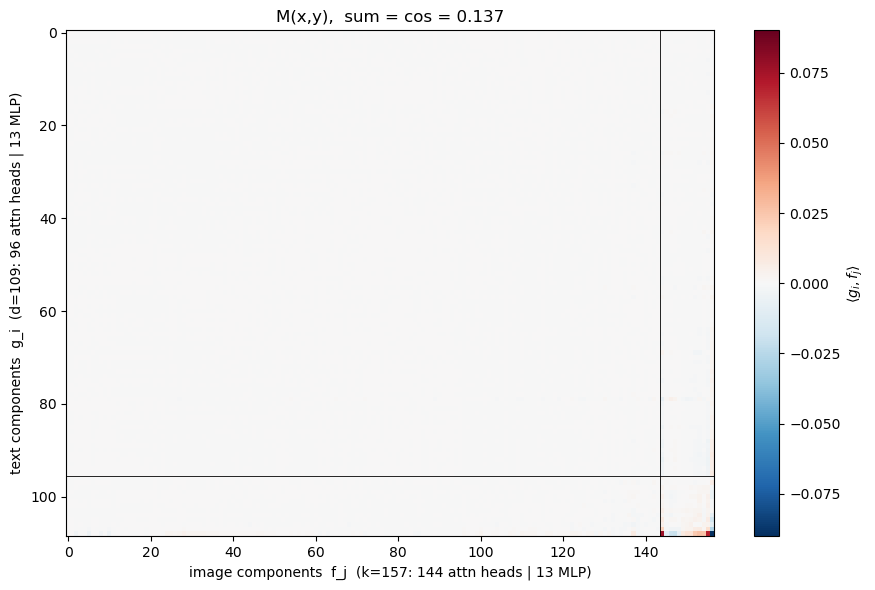

In [4]:
# Heatmap of one interaction matrix. Rows 0..95 = text attn heads, 96..108 = text MLP slots;
# cols 0..143 = image attn heads, 144..156 = image MLP slots.
fig, ax = plt.subplots(figsize=(9,6))
vmax = np.abs(M).max()
im = ax.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xlabel("image components  f_j  (k=157: 144 attn heads | 13 MLP)")
ax.set_ylabel("text components  g_i  (d=109: 96 attn heads | 13 MLP)")
ax.set_title(f"M(x,y),  sum = cos = {M.sum():.3f}")
ax.axvline(143.5, color="k", lw=.6); ax.axhline(95.5, color="k", lw=.6)
fig.colorbar(im, ax=ax, label=r"$\langle g_i, f_j\rangle$")
plt.tight_layout(); plt.show()


## 3. Batched property checks over many pairs

Sanity-check that the identities hold for *every* pair in a batch, not just the one above.

In [5]:
nb = 120
Fb = F_all[:nb]                      # [nb, k, m]
Gb = G_all[:nb]                      # [nb, d, m]
Mb = np.einsum('nid,njd->nij', Gb, Fb)      # [nb, d, k]

cos_b = np.einsum('nd,nd->n', Gb.sum(1), Fb.sum(1))
print("max |sum(M) - cos|           =", np.abs(Mb.sum((1,2)) - cos_b).max())
print("max |sum(rows) - sum(cols)|  =", np.abs(Mb.sum(2).sum(1) - Mb.sum(1).sum(1)).max())
print("max |sum(rows) - cos|        =", np.abs(Mb.sum(2).sum(1) - cos_b).max())
print("cos(theta) over pairs: mean %.3f  range [%.3f, %.3f]" % (cos_b.mean(), cos_b.min(), cos_b.max()))


max |sum(M) - cos|           = 2.220446049250313e-16
max |sum(rows) - sum(cols)|  = 1.717376241217039e-16
max |sum(rows) - cos|        = 1.942890293094024e-16
cos(theta) over pairs: mean 0.052  range [-0.186, 0.228]


## 4. Rank of $M$, and of the small matrices $\mathbf G$ and $\mathbf F$

For each matrix we report three notions of rank:
* **exact rank** — `np.linalg.matrix_rank` (algebraic, machine-precision tol);
* **99%-energy rank** — smallest $r$ with $\sum_{\le r}\sigma^2 \ge 0.99\sum\sigma^2$ (effective dimensionality);
* **stable rank** — $\lVert\cdot\rVert_F^2/\sigma_1^2$ (how spread the spectrum is; $1$ = rank-1-like).

Because $M=\mathbf G\mathbf F^\top$, we also expect $\operatorname{rank}M=\min(\operatorname{rank}\mathbf G,\operatorname{rank}\mathbf F)$ generically.

In [6]:
def rank_stats(X, tol_dim):
    '''X: [n, p, q] batch. Returns per-sample (exact, energy99, stable) using one SVD each.'''
    s = np.linalg.svd(X, compute_uv=False)                      # [n, min(p,q)]
    tol   = s[:, :1] * tol_dim * np.finfo(float).eps
    exact = (s > tol).sum(1)
    en    = (np.cumsum(s**2,1)/(s**2).sum(1,keepdims=True) < 0.99).sum(1) + 1
    stab  = (s**2).sum(1) / s[:,0]**2
    return exact, en, stab, s

exF, enF, stF, sF = rank_stats(Fb, max(K,512))
exG, enG, stG, sG = rank_stats(Gb, max(D,512))
exM, enM, stM, sM = rank_stats(Mb, max(D,K))

def line(name, ex, en, st, cap):
    print(f"{name:22s} exact {ex.mean():6.1f}/{cap:<4d}  99%-energy {en.mean():6.1f}  stable {st.mean():5.2f}")

print("F  image small-matrix  [k=157 x m=512]");  line("  rank(F)", exF, enF, stF, K)
print("G  text  small-matrix  [d=109 x m=512]");  line("  rank(G)", exG, enG, stG, D)
print("M  interaction         [d=109 x k=157]");  line("  rank(M)", exM, enM, stM, min(D,K))

pred = np.minimum(exG, exF)
print(f"\nrank(M) == min(rank G, rank F) in {(exM==pred).sum()}/{nb} pairs")


F  image small-matrix  [k=157 x m=512]
  rank(F)              exact  157.0/157   99%-energy   71.2  stable  3.14
G  text  small-matrix  [d=109 x m=512]
  rank(G)              exact  109.0/109   99%-energy   62.4  stable  2.29
M  interaction         [d=109 x k=157]
  rank(M)              exact  109.0/109   99%-energy    8.5  stable  1.08

rank(M) == min(rank G, rank F) in 120/120 pairs


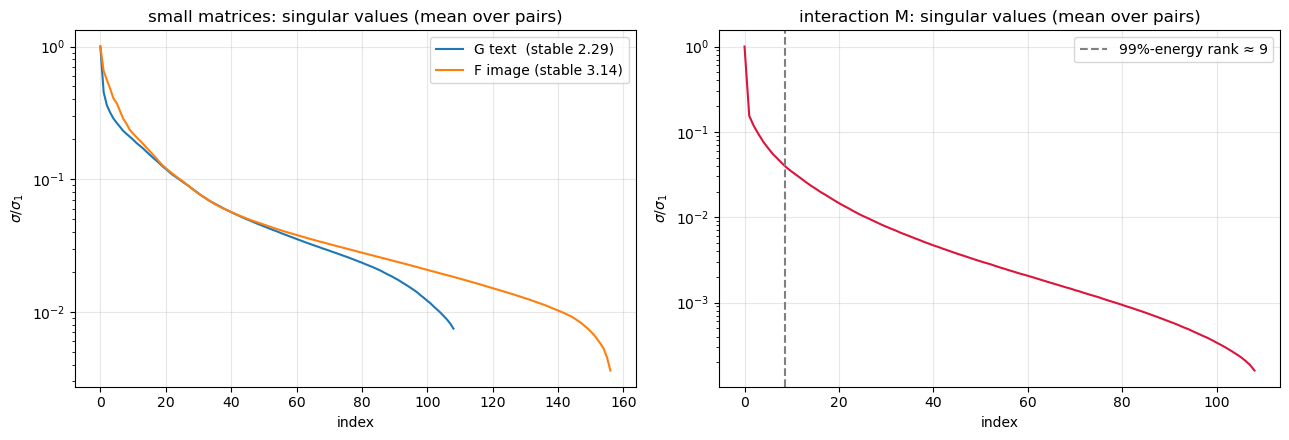

In [7]:
# Mean singular-value spectra (normalized to sigma_1), to see the effective-rank collapse.
def mean_spec(s):
    s = s / s[:, :1]
    return s.mean(0)

fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].semilogy(mean_spec(sG), label=f"G text  (stable {stG.mean():.2f})")
ax[0].semilogy(mean_spec(sF), label=f"F image (stable {stF.mean():.2f})")
ax[0].set_title("small matrices: singular values (mean over pairs)")
ax[0].set_xlabel("index"); ax[0].set_ylabel(r"$\sigma / \sigma_1$"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].semilogy(mean_spec(sM), color="crimson")
ax[1].axvline(enM.mean(), ls="--", color="gray", label=f"99%-energy rank ≈ {enM.mean():.0f}")
ax[1].set_title(f"interaction M: singular values (mean over pairs)")
ax[1].set_xlabel("index"); ax[1].set_ylabel(r"$\sigma / \sigma_1$"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 5. Reading of the results (ViT-B-16, imagenet images $\times$ bias-text)

* **$\mathbf G$ and $\mathbf F$ are exactly full rank** ($109/109$ and $157/157$): the per-head / per-MLP
  contribution vectors are **linearly independent** — no component is an exact combination of the others.
* **But their spectra collapse** — *stable rank* $\approx 2\!-\!3$ and 99% of the energy sits in $\sim\!65\!-\!70$
  directions. A single dominant direction carries most of the norm: this is the **shared LN-bias vector**
  (Q2) that is added, as the same constant, to every component — plus the near-constant CLS/EOS mean term.
* **$M$ is algebraically full rank $109=\min(d,k)$**, exactly matching $\min(\operatorname{rank}\mathbf G,\operatorname{rank}\mathbf F)$,
  **yet its effective rank is tiny — $\sim\!7$ directions hold 99% of the energy.** So although $M$ has
  $109\times157\approx1.7\times10^4$ entries, the image$\leftrightarrow$text component interaction that produces
  the cosine similarity lives in a $\lesssim 10$-dimensional subspace. That is the quantitative hook for a
  low-rank / few-concept description of how the two towers align.

*Everything above is exact (identities verified to $10^{-16}$); to change the model/datasets edit `MODEL`, `IMG`, `TXT` in §0.*

## 6. Are the variance directions "clear"? — concentration & stability of $M$'s singular vectors

Write the per-pair SVD $M(x,y)=\sum_r \sigma_r\, u_r v_r^\top$. Each **left vector $u_r\in\mathbb R^{d}$**
lives in *text-component* space (which of the 109 text heads/MLPs load on the $r$-th mode) and each
**right vector $v_r\in\mathbb R^{k}$** in *image-component* space (which of the 157 image heads/MLPs).
"Clear/spiky" means a vector has a few large entries and many near-zero ones. We quantify it two ways:

* **participation ratio** $\mathrm{PR}(w)=\dfrac{(\sum_i w_i^2)^2}{\sum_i w_i^4}$ = *effective number of active
  components* (for a unit vector: $\mathrm{PR}=1\Rightarrow$ one component; $\mathrm{PR}=\dim\Rightarrow$ uniform).
  A dense random unit vector has $\mathrm{PR}\approx\dim/3$ ($\approx 36$ in $\mathbb R^{109}$, $\approx 52$ in $\mathbb R^{157}$).
* **top-5 mass** = energy fraction carried by a vector's 5 largest entries.

Then we ask whether these directions are the **same across the dataset** or **pair-dependent**, via
(a) mean pairwise $|\cos|$ between the $r$-th vectors over pairs (sign-invariant), and (b) mean Jaccard
overlap of their top-5 active-component sets.

In [8]:
# SVD of the per-pair interaction matrices (reuse Mb: [nb, d=109, k=157] from §3)
Um, Sm, Vtm = np.linalg.svd(Mb, full_matrices=False)     # Um [nb,109,109], Vtm [nb,109,157]

def PR(w):                       # participation ratio along last axis
    w2 = w**2
    return (w2.sum(-1)**2) / (w2**2).sum(-1)
def top_mass(w, k=5):
    w2 = np.sort(w**2, -1)[..., ::-1]
    return w2[..., :k].sum(-1) / w2.sum(-1)

print("d(text)=109  k(image)=157   dense-random PR ~ 36 (R^109) / ~52 (R^157)\n")
print(" dir |  U(text): PR/109  top5 |  V(image): PR/157  top5")
for r in range(6):
    u = Um[:, :, r]; v = Vtm[:, r, :]
    print(f"  {r+1}  |     {PR(u).mean():5.1f}      {top_mass(u).mean():.2f} |      {PR(v).mean():5.1f}      {top_mass(v).mean():.2f}")

# component index -> readable label
def lbl_txt(i): return f"a{i//8}.{i%8}" if i < 96 else f"MLP{i-96}"   # 96 attn (12x8) + 13 mlp
def lbl_img(j): return f"a{j//12}.{j%12}" if j < 144 else f"MLP{j-144}" # 144 attn (12x12) + 13 mlp

# which components dominate the top-1 mode, and how consistent across pairs
tu = np.abs(Um[:, :, 0]).argmax(1); tv = np.abs(Vtm[:, 0, :]).argmax(1)
from collections import Counter
print("\ntop-1 mode argmax  text comp:", [(lbl_txt(i), c) for i, c in Counter(tu).most_common(3)])
print("top-1 mode argmax  image comp:", [(lbl_img(j), c) for j, c in Counter(tv).most_common(3)])


d(text)=109  k(image)=157   dense-random PR ~ 36 (R^109) / ~52 (R^157)

 dir |  U(text): PR/109  top5 |  V(image): PR/157  top5
  1  |       1.3      0.94 |        3.4      0.91
  2  |       7.4      0.70 |        3.5      0.87
  3  |       9.4      0.63 |        4.7      0.82
  4  |      10.1      0.60 |        5.5      0.78
  5  |      10.3      0.60 |        5.9      0.75
  6  |      12.0      0.56 |        6.9      0.71

top-1 mode argmax  text comp: [('MLP12', 120)]
top-1 mode argmax  image comp: [('MLP12', 120)]


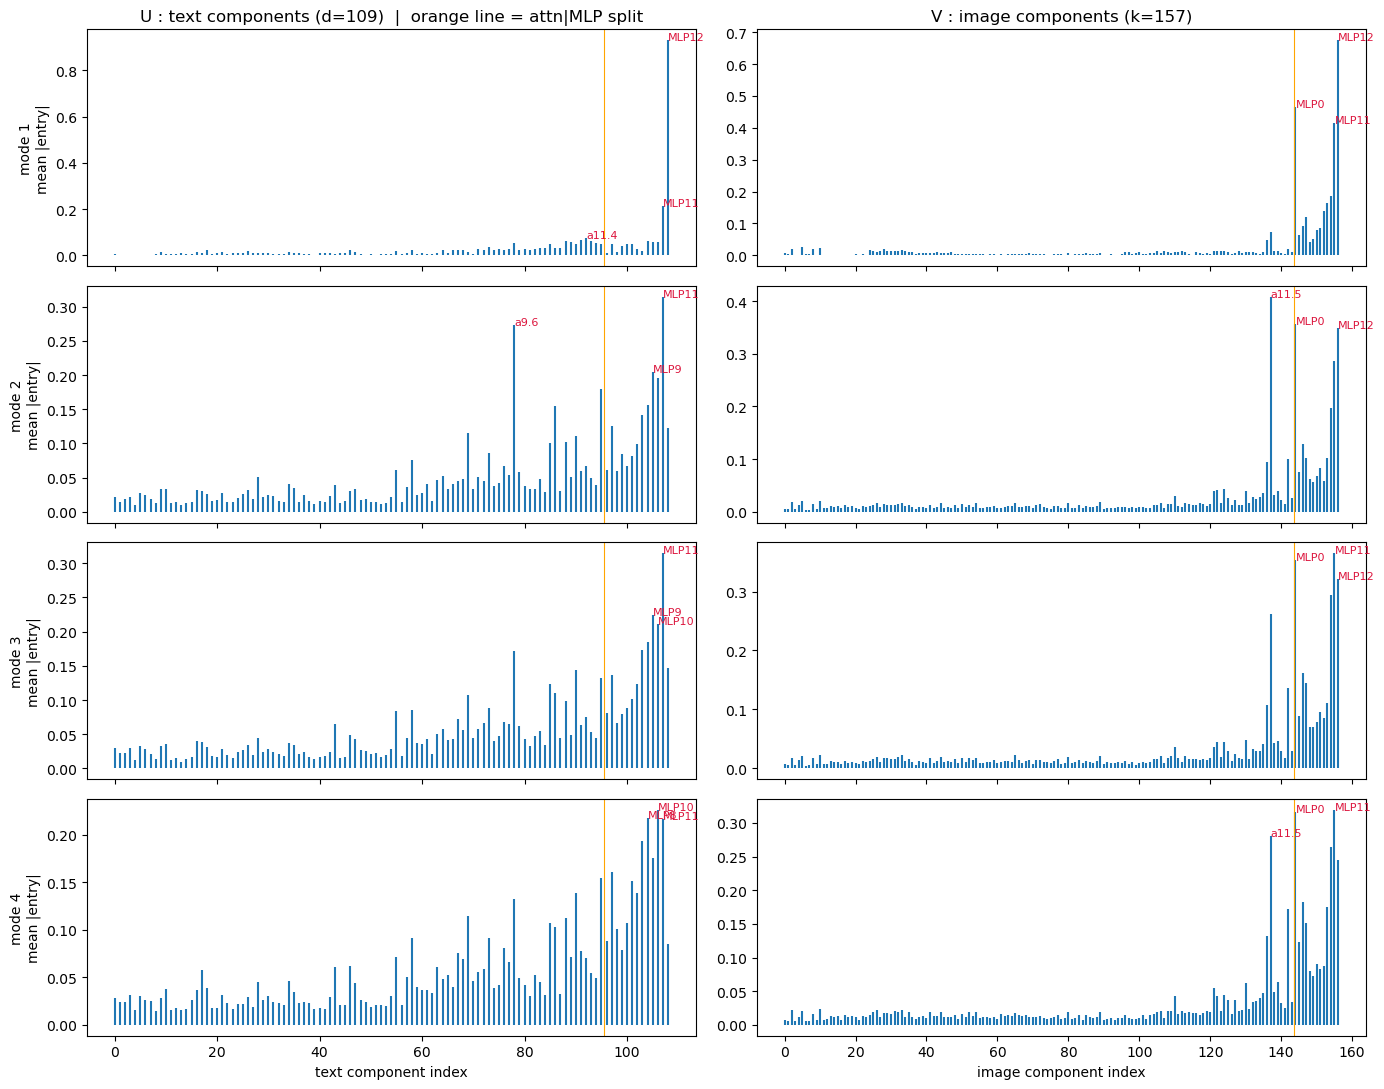

In [9]:
# Stem plots: mean |u_r| (text) and |v_r| (image) over pairs, for the top 4 modes.
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex="col")
for r in range(4):
    mu = np.abs(Um[:, :, r]).mean(0)     # [109]
    mv = np.abs(Vtm[:, r, :]).mean(0)    # [157]
    axL, axR = axes[r]
    axL.stem(mu, markerfmt=" ", basefmt=" "); axL.axvline(95.5, color="orange", lw=.8)
    axR.stem(mv, markerfmt=" ", basefmt=" "); axR.axvline(143.5, color="orange", lw=.8)
    axL.set_ylabel(f"mode {r+1}\nmean |entry|")
    for j in np.argsort(mu)[::-1][:3]: axL.annotate(lbl_txt(j), (j, mu[j]), fontsize=8, color="crimson")
    for j in np.argsort(mv)[::-1][:3]: axR.annotate(lbl_img(j), (j, mv[j]), fontsize=8, color="crimson")
axes[0,0].set_title("U : text components (d=109)  |  orange line = attn|MLP split")
axes[0,1].set_title("V : image components (k=157)")
axes[3,0].set_xlabel("text component index"); axes[3,1].set_xlabel("image component index")
plt.tight_layout(); plt.show()


In [10]:
# Stability across the dataset: same direction everywhere, or pair-dependent?
def align(vs):                       # mean pairwise |cos| across pairs
    A = np.abs(vs @ vs.T); iu = np.triu_indices(len(vs), 1); return A[iu].mean()
def top5_jaccard(w):
    sets = [set(np.argsort(np.abs(x))[::-1][:5]) for x in w]
    n = len(sets)
    return np.mean([len(sets[a] & sets[b]) / len(sets[a] | sets[b])
                    for a in range(n) for b in range(a+1, n)])

print(" dir | V mean|cos|  V top5-Jaccard | U mean|cos|  U top5-Jaccard")
for r in range(5):
    v = Vtm[:, r, :]; u = Um[:, :, r]
    print(f"  {r+1}  |   {align(v):.3f}       {top5_jaccard(v):.3f}     |   {align(u):.3f}       {top5_jaccard(u):.3f}")


 dir | V mean|cos|  V top5-Jaccard | U mean|cos|  U top5-Jaccard
  1  |   0.983       0.844     |   0.985       0.435
  2  |   0.417       0.376     |   0.314       0.203
  3  |   0.411       0.399     |   0.305       0.190
  4  |   0.302       0.326     |   0.213       0.151
  5  |   0.294       0.281     |   0.216       0.158


**Reading (ViT-B-16, imagenet $\times$ bias-text).**

* **Yes, the top directions are very clear.** Mode 1 has $\mathrm{PR}(u)\approx1.3$ (≈ *one* text component) and
  $\mathrm{PR}(v)\approx3$ (≈ 3 image components), with >90% of the energy in the top-5 entries — far below the
  dense-random baseline. On both sides the single dominant component is the **last-layer MLP** (`MLP12`), and it
  is `MLP12` in essentially **every pair** (argmax counter). Mode 1 is also *frozen* across the dataset:
  mean $|\cos|\approx0.99$, top-5 Jaccard $\approx0.93$.
* **But mode 1 is the boring DC / LN-bias direction** — the common vector added to every component (§0, Q2).
  It is strong and stable, yet carries little discriminative signal (see §7: mean-ablating `MLP12` barely moves
  accuracy).
* **Modes 2+ are the *strong & varying* interactions.** They stay concentrated ($\mathrm{PR}\approx 8\text{–}12$
  text, $4\text{–}6$ image — still much sparser than random), but they are **pair-dependent**: mean $|\cos|$ drops
  to $0.5\!\to\!0.27$ and top-5 Jaccard to $0.36\!\to\!0.24$ for modes 2→5. So the *concentration is stable*
  (always a handful of heads), but *which* heads light up changes per image/text — exactly the signal we want to
  isolate for the task below.

## 7. Do the strong & varying components carry the task signal? — keep-only vs mean-ablate

We now test, on the real **zero-shot imagenet** task (5000 images, 1000-class OpenAI-template classifier),
whether the components that dominate the varying interaction are the ones that matter. Score of image $y$ for
class $c$ is $\langle F(y), T_c\rangle=\sum_j\langle f_j(y),T_c\rangle$, so each **image component $j$** contributes
$\langle f_j(y),T_c\rangle$ to the logits.

**Ranking ("strong & varying").** For each image component $j$ we take the variance across images of its
logit contribution, averaged over classes: $\;\mathrm{score\_var}[j]=\mathbb E_c\big[\mathrm{Var}_y\,\langle f_j(y),T_c\rangle\big]$.
This is the classifier-projected version of the $\mathrm{Var}[S_{ab}]$ ranking — it rewards components whose
image$\leftrightarrow$class interaction *varies* across the dataset (discriminative), not merely large-but-constant ones.

**Two interventions**, re-summed then L2-renormalized before the cosine (so we always classify a unit vector):
* **keep-only top-$K$** (zero-ablate the rest): $\;\hat F=\sum_{j\in S_K} f_j(y)$ — does discarding everything but the
  top varying components *keep / improve* accuracy?
* **mean-ablate top-$K$** (keep the rest intact): replace $f_j(y)\!\to\!\mathbb E_y f_j$ for $j\in S_K$ — does removing
  the image-specific part of just those components *collapse* accuracy?

Controls for keep-only: same $K$ but **random** or **bottom-ranked** (lowest-variance) components.

In [11]:
# Full imagenet image-component tensor + classifier (independent of the §0 sample of 200).
lab = np.asarray(np.load(f"{DATA}/{IMG}_labels_{MODEL}_seed_{SEED}.npy"))
Cls = np.asarray(np.load(f"{DATA}/{IMG}_classifier_{MODEL}.npy"), np.float32)     # [512, 1000]
Ffull = stack(np.asarray(Ia, np.float32), np.asarray(Im, np.float32))            # [N, 157, 512]
Nimg = Ffull.shape[0]
print("image components", Ffull.shape, " classifier", Cls.shape, " images", Nimg)

def zs_acc(emb):
    e = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    return float((e @ Cls).argmax(1).__eq__(lab).mean())

full_emb = Ffull.sum(1)
mean_comp = Ffull.mean(0)                                   # [157, 512] dataset-mean per component
full_acc = zs_acc(full_emb)
print("full zero-shot accuracy =", round(full_acc, 4))

# rank image components by variance of their logit contribution (mean over classes)
score_var = np.empty(K)
for j in range(K):
    score_var[j] = (Ffull[:, j, :] @ Cls).var(0).mean()
order = np.argsort(score_var)[::-1]                         # strong+varying first
print("top-12 varying image components:", [lbl_img(j) for j in order[:12]])


image components (5000, 157, 512)  classifier (512, 1000)  images 5000


full zero-shot accuracy = 0.695


top-12 varying image components: ['MLP12', 'a11.5', 'MLP11', 'a11.4', 'a11.7', 'a11.10', 'a11.3', 'a10.10', 'a11.8', 'MLP10', 'a10.4', 'MLP9']


       K   keepTop  keepRand   keepBot   mAblTop  mAblRand   mAblBot   (full=0.695)
       1    0.0000    0.0222    0.0010    0.6726    0.6928    0.6950
       2    0.1260    0.0034    0.0010    0.5338    0.6958    0.6954
       3    0.1516    0.0020    0.0010    0.5124    0.6950    0.6952
       5    0.2618    0.1044    0.0010    0.4330    0.6912    0.6956
       8    0.4322    0.0782    0.0010    0.2762    0.6902    0.6958
      10    0.5316    0.0112    0.0010    0.2318    0.6964    0.6962
      15    0.5854    0.1236    0.0010    0.1124    0.6748    0.6960
      20    0.6118    0.0494    0.0010    0.0784    0.6914    0.6954
      30    0.6378    0.2812    0.0010    0.0184    0.4244    0.6962
      50    0.6232    0.0474    0.0010    0.0028    0.6804    0.6956
      80    0.6300    0.4356    0.0008    0.0020    0.2486    0.6960
     120    0.6778    0.6328    0.0092    0.0010    0.0736    0.6918
     157    0.6950    0.6950    0.6950    0.0010    0.0010    0.0010


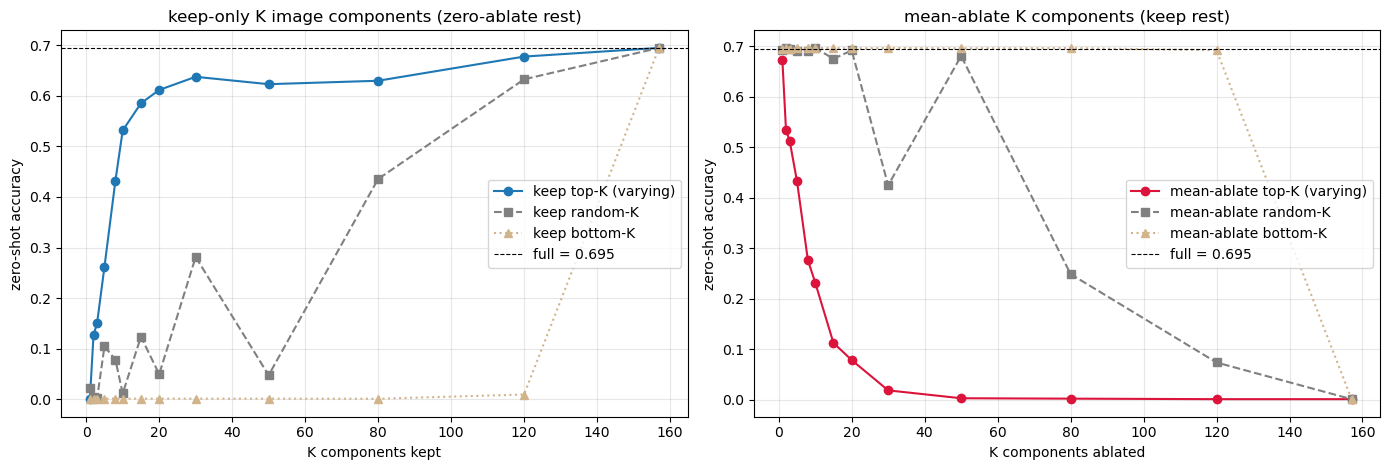

In [12]:
# Accuracy sweeps
Ks = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 80, 120, 157]
rng = np.random.default_rng(0)
res = {k: [] for k in ["keepTop","keepRand","keepBot","meanAblTop","meanAblRand","meanAblBot"]}
def mean_ablate(idx):    # replace components `idx` by their dataset mean, keep the rest
    return full_emb - Ffull[:, idx, :].sum(1) + mean_comp[idx].sum(0)
for k in Ks:
    top = order[:k]; bot = order[-k:]; rnd = rng.choice(K, k, replace=False)
    res["keepTop"].append(     zs_acc(Ffull[:, top, :].sum(1)))
    res["keepRand"].append(    zs_acc(Ffull[:, rnd, :].sum(1)))
    res["keepBot"].append(     zs_acc(Ffull[:, bot, :].sum(1)))
    res["meanAblTop"].append(  zs_acc(mean_ablate(top)))
    res["meanAblRand"].append( zs_acc(mean_ablate(rnd)))
    res["meanAblBot"].append(  zs_acc(mean_ablate(bot)))

hdr = ["K","keepTop","keepRand","keepBot","mAblTop","mAblRand","mAblBot"]
print("  ".join(f"{h:>8}" for h in hdr) + f"   (full={full_acc:.3f})")
for i, k in enumerate(Ks):
    row = [k, res["keepTop"][i], res["keepRand"][i], res["keepBot"][i],
           res["meanAblTop"][i], res["meanAblRand"][i], res["meanAblBot"][i]]
    print(f"{k:>8}  " + "  ".join(f"{v:>8.4f}" for v in row[1:]))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].plot(Ks, res["keepTop"],  "o-", label="keep top-K (varying)")
ax[0].plot(Ks, res["keepRand"], "s--", label="keep random-K", color="gray")
ax[0].plot(Ks, res["keepBot"],  "^:", label="keep bottom-K", color="tan")
ax[0].axhline(full_acc, color="k", lw=.8, ls="--", label=f"full = {full_acc:.3f}")
ax[0].set_title("keep-only K image components (zero-ablate rest)")
ax[0].set_xlabel("K components kept"); ax[0].set_ylabel("zero-shot accuracy"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(Ks, res["meanAblTop"],  "o-",  color="crimson", label="mean-ablate top-K (varying)")
ax[1].plot(Ks, res["meanAblRand"], "s--", color="gray",    label="mean-ablate random-K")
ax[1].plot(Ks, res["meanAblBot"],  "^:",  color="tan",     label="mean-ablate bottom-K")
ax[1].axhline(full_acc, color="k", lw=.8, ls="--", label=f"full = {full_acc:.3f}")
ax[1].set_title("mean-ablate K components (keep rest)")
ax[1].set_xlabel("K components ablated"); ax[1].set_ylabel("zero-shot accuracy"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


### Reading of the keep / ablate experiment

**Keep-only (zero-ablate the rest) — does it improve?** *No, but it recovers most of the accuracy from very few
components.* Keeping the top **~30** varying image components (of 157) recovers $\approx0.64$ of the full $0.695$
(≈92%); keeping the top ~20 already gives $\approx0.61$. It plateaus slightly **below** full and only returns to
$0.695$ once (almost) all components are back — so on clean imagenet, discarding the tail does **not** beat the full
embedding, it just shows the task lives in a small set of components. The **controls** confirm the ranking is
meaningful: keeping the *bottom* (lowest-variance, early-layer) components gives $\approx0.001$ (chance is
$0.001$ for 1000 classes), and *random*-$K$ is far below top-$K$ at every budget.

> Caveat visible at $K{=}1$: keep-only-`MLP12` scores $0.000$ even though it tops the variance ranking — because
> `MLP12` is the DC/LN-bias mode (§6). Its logit *variance* is inflated by its large norm, but alone it is not
> class-discriminative. The genuinely discriminative varying components are the **late attention heads**
> (`a11.5, a11.4, a11.7, a10.10, …`), which is why accuracy climbs steeply once those enter (K≥8).

**Mean-ablate the top-K — does accuracy drop a lot?** *Yes, sharply, and specifically.* Replacing just the top
**~15–20** varying components by their dataset mean collapses accuracy from $0.695$ to $\approx0.08\text{–}0.11$; the
top **30** drive it to $\approx0.02$ (essentially dead). The **random-K** and **bottom-K** mean-ablation controls
(same panel) stay close to full for a long time — mean-ablating low-variance / random components barely changes
accuracy — so the collapse is driven by *those specific* strong & varying components, not by ablating "any 20
components". Mean-ablating the DC component alone (`MLP12`, K=1) also barely dents it ($0.695\!\to\!0.673$).

**Takeaway for the task.** The varying (mode-2+) interaction structure of $M$ is not a mathematical curiosity: the
same handful of late-layer heads that light up those pair-dependent modes are precisely the ones whose
mean-ablation destroys zero-shot accuracy and whose retention reconstructs it. That is the concrete, testable
handle for isolating "strong & varying" component interactions.

## 8. Reduce to the top components → smaller $A$, $B$, $M$; per-class mean & variance

We now **shrink the small matrices** to the top components found in §6–§7 and study how the reduced
$A$ (text), $B$ (image) and $M=A B^\top$ behave *within a class* versus *across very different classes*.

**Modeling choices (stated explicitly).**
* For a per-class study the text side must be **class-specific**, so here $A$ is the decomposed CLIP embedding
  of each **imagenet class name** (`imagenet_classnames_*_text`), one $A(c)$ per class — *not* the bias-text set of
  §1–§7. Note this is a **single class-name prompt**, so $\sum$ of its components is unit-norm but does **not**
  equal the 80-template zero-shot classifier used for accuracy in §7 (cos ≈ 0.89); fine for a structural study.
* **Reduced index sets** ($d'=k'=16$): image components = top-16 by the §7 logit-variance ranking; text
  components = top-16 by across-class variance of the class-name decompositions.
* **Averaging unit.** $B$ and $M(y,c(y))$ are averaged/var'd over the **images of a class**; $A$ is one vector per
  class, so its "variance" is taken **across classes** (between-class). The imagenet subset has only ~5 images per
  class, so within-class means are indicative and within-class *variances* are noisy (pooled over all 1000 classes
  where it matters).
* **10 "very different" classes** are picked by farthest-point sampling on the class embeddings.

In [13]:
# ---- text (class-name) components -> A(c);  reuse Ffull/order/lab/Cls/lbl_* from §6-§7 ----
Aa = np.load(f"{DATA}/imagenet_classnames_attn_text_{MODEL}_seed_{SEED}.npy", mmap_mode="r")
Am = np.load(f"{DATA}/imagenet_classnames_mlp_text_{MODEL}_seed_{SEED}.npy",  mmap_mode="r")
Al = np.asarray(np.load(f"{DATA}/imagenet_classnames_labels_text_{MODEL}_seed_{SEED}.npy"))
A_all = stack(np.asarray(Aa, np.float32), np.asarray(Am, np.float32))      # [1000,109,512]
A_by_class = A_all[np.argsort(Al)]                                          # row c == class c

print("images per class:", np.bincount(lab).min(), "to", np.bincount(lab).max())

# reduced component sets
sv_txt = A_by_class.astype(np.float64).var(0).mean(1)                       # across-class var per text comp
Ti = np.sort(np.argsort(sv_txt)[::-1][:16])                                 # 16 text comps
Ii = np.sort(order[:16])                                                    # 16 image comps (from §7 ranking)
txt_lab = [lbl_txt(i) for i in Ti]; img_lab = [lbl_img(j) for j in Ii]
print("reduced TEXT comps:", txt_lab)
print("reduced IMG  comps:", img_lab)

A = A_by_class[:, Ti, :]                    # [1000, 16, 512]   text small-matrix per class
B = Ffull[:, Ii, :]                         # [5000, 16, 512]   image small-matrix per image (float32)

# 10 maximally-different classes via farthest-point sampling on class embeddings
X = Cls.T / np.linalg.norm(Cls.T, axis=1, keepdims=True)
sel = [0]; dmin = 1 - X @ X[0]
for _ in range(9):
    i = int(dmin.argmax()); sel.append(i); dmin = np.minimum(dmin, 1 - X @ X[i])
sel = np.array(sel); print("10 diverse classes:", sel)

# per-image reduced interaction M(y, c(y)) = A(class of y) @ B(y)^T   -> [N,16,16]
Mfull = np.einsum('nid,njd->nij', A[lab], B).astype(np.float64)
print("Mfull", Mfull.shape)


images per class: 5 to 5
reduced TEXT comps: ['a8.0', 'a9.0', 'a9.6', 'a10.6', 'a11.0', 'a11.1', 'a11.2', 'a11.3', 'a11.7', 'MLP6', 'MLP7', 'MLP8', 'MLP9', 'MLP10', 'MLP11', 'MLP12']
reduced IMG  comps: ['a10.2', 'a10.4', 'a10.5', 'a10.10', 'a11.3', 'a11.4', 'a11.5', 'a11.6', 'a11.7', 'a11.8', 'a11.10', 'MLP8', 'MLP9', 'MLP10', 'MLP11', 'MLP12']


10 diverse classes: [  0 451 956 181 135 369 300 602 351 666]


Mfull (5000, 16, 16)


### 8.1 $M$ — mean and variance per class (10 diverse classes + full imagenet)
Reduced $16\times16$: rows = text components, cols = image components.

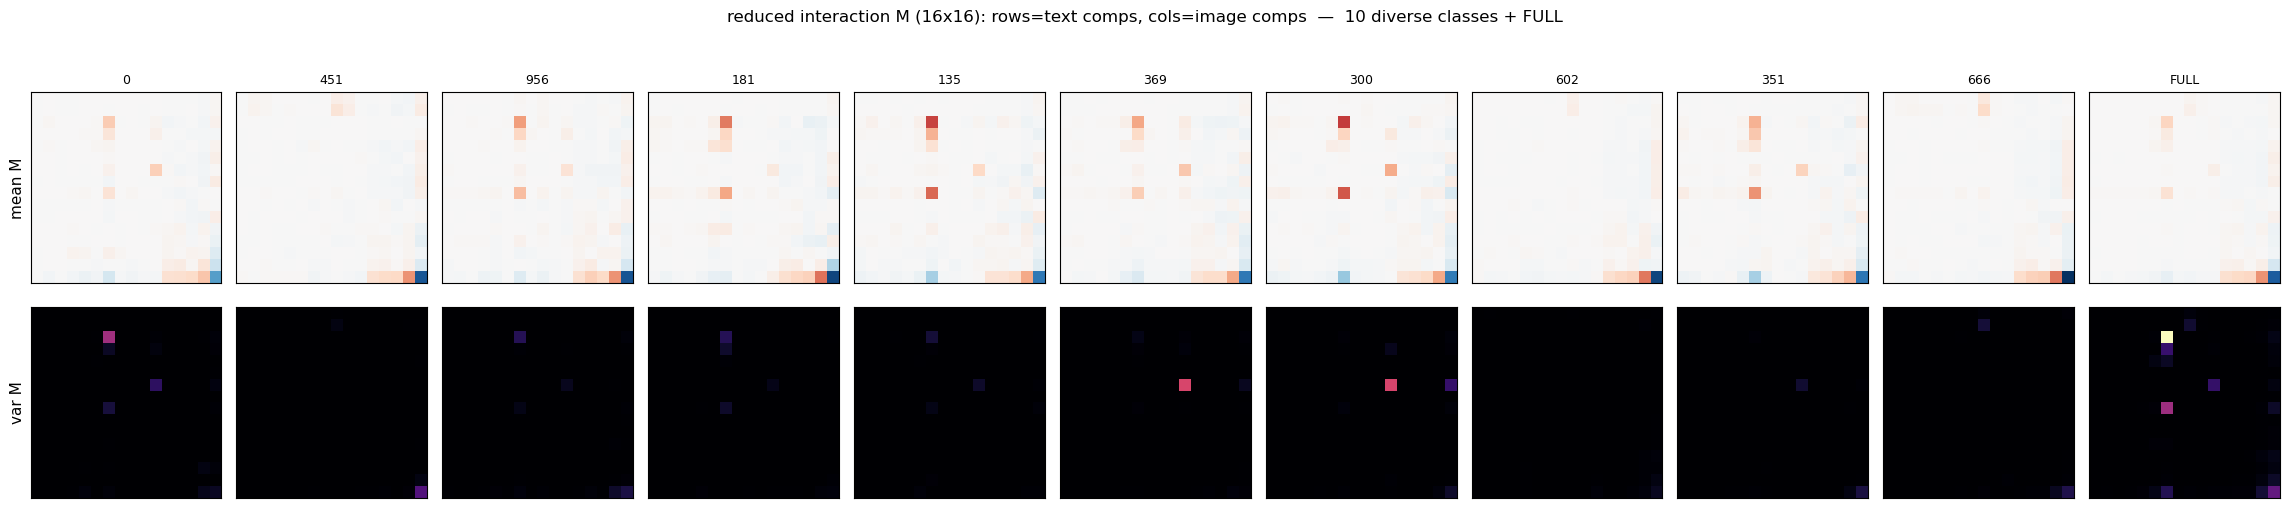

In [14]:
groups = list(sel) + ["FULL"]
meanM = [Mfull[lab==c].mean(0) if c!="FULL" else Mfull.mean(0) for c in groups]
varM  = [Mfull[lab==c].var(0)  if c!="FULL" else Mfull.var(0)  for c in groups]
vmax_m = np.abs(np.stack(meanM)).max(); vmax_v = np.stack(varM).max()

fig, ax = plt.subplots(2, 11, figsize=(23, 5.2))
for j,(mm,vv,g) in enumerate(zip(meanM, varM, groups)):
    ax[0,j].imshow(mm, cmap="RdBu_r", vmin=-vmax_m, vmax=vmax_m); ax[0,j].set_title(str(g), fontsize=9)
    ax[1,j].imshow(vv, cmap="magma",  vmin=0, vmax=vmax_v)
    for r in (0,1): ax[r,j].set_xticks([]); ax[r,j].set_yticks([])
ax[0,0].set_ylabel("mean M", fontsize=11); ax[1,0].set_ylabel("var M", fontsize=11)
fig.suptitle("reduced interaction M (16x16): rows=text comps, cols=image comps  —  10 diverse classes + FULL", y=1.02)
plt.tight_layout(); plt.show()


M full: 2% of entries ~constant (CV<0.3), 80% strongly varying (CV>1)
largest |mean| entries (the constant DC/MLP block): [('MLP12', 'MLP12', 0.095), ('MLP12', 'MLP11', 0.051), ('a9.6', 'a11.5', 0.024), ('MLP12', 'MLP10', 0.024), ('MLP12', 'MLP9', 0.022)]
largest within-image std entries (varying):         [('a9.6', 'a11.5', 0.029), ('a11.7', 'a11.5', 0.019), ('MLP12', 'MLP12', 0.016), ('a10.6', 'a11.5', 0.013), ('a11.2', 'a11.10', 0.013)]


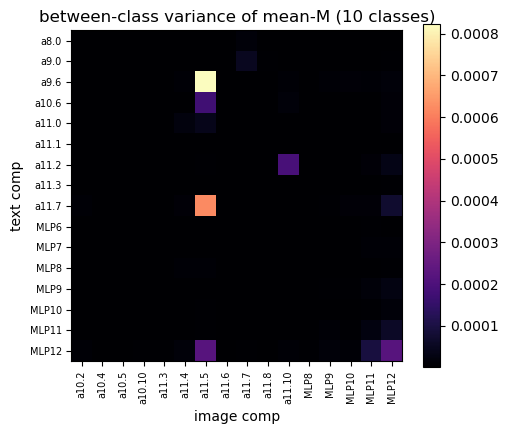

most class-discriminative M entries: [('a9.6', 'a11.5', 0.001), ('a11.7', 'a11.5', 0.001), ('MLP12', 'a11.5', 0.0), ('MLP12', 'MLP12', 0.0), ('a11.2', 'a11.10', 0.0)]


In [15]:
# What is constant vs varying, quantitatively, over full imagenet + what is class-discriminative
mM, sM = Mfull.mean(0), Mfull.std(0)
cv = np.abs(sM) / (np.abs(mM) + 1e-9)
print(f"M full: {(cv<0.3).mean()*100:.0f}% of entries ~constant (CV<0.3), {(cv>1).mean()*100:.0f}% strongly varying (CV>1)")
def top_entries(Mtx, k=5):
    idx = np.dstack(np.unravel_index(np.argsort(Mtx.ravel())[::-1][:k], Mtx.shape))[0]
    return [(txt_lab[a], img_lab[b], round(float(Mtx[a,b]),3)) for a,b in idx]
print("largest |mean| entries (the constant DC/MLP block):", top_entries(np.abs(mM)))
print("largest within-image std entries (varying):        ", top_entries(sM))

# between-class variance of the class-mean M (10 diverse classes) -> what separates classes
meanM_c = np.stack([Mfull[lab==c].mean(0) for c in sel])
betwM = meanM_c.var(0)
fig, ax = plt.subplots(figsize=(5.2,4.4))
im = ax.imshow(betwM, cmap="magma"); ax.set_title("between-class variance of mean-M (10 classes)")
ax.set_xticks(range(16)); ax.set_xticklabels(img_lab, rotation=90, fontsize=7)
ax.set_yticks(range(16)); ax.set_yticklabels(txt_lab, fontsize=7)
ax.set_xlabel("image comp"); ax.set_ylabel("text comp"); fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()
print("most class-discriminative M entries:", top_entries(betwM))


### 8.2 $A$ (text) and $B$ (image) — mean and variance heatmaps
$A,B$ are $16\times512$ (component $\times$ embedding dim). We show the full-imagenet mean and the variance
(for $A$: across classes; for $B$: within-class pooled and between-class), then a per-component summary that
directly answers *"which components are constant and which vary"*.

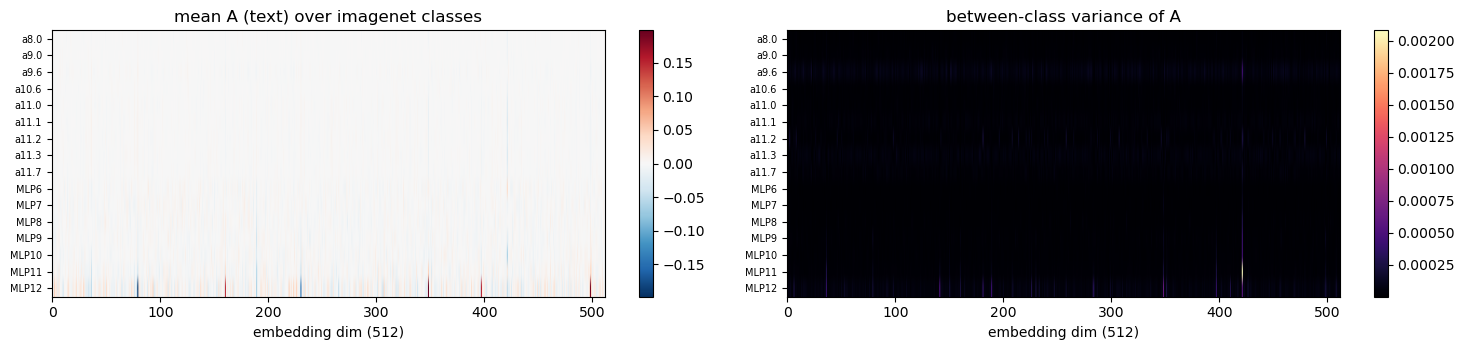

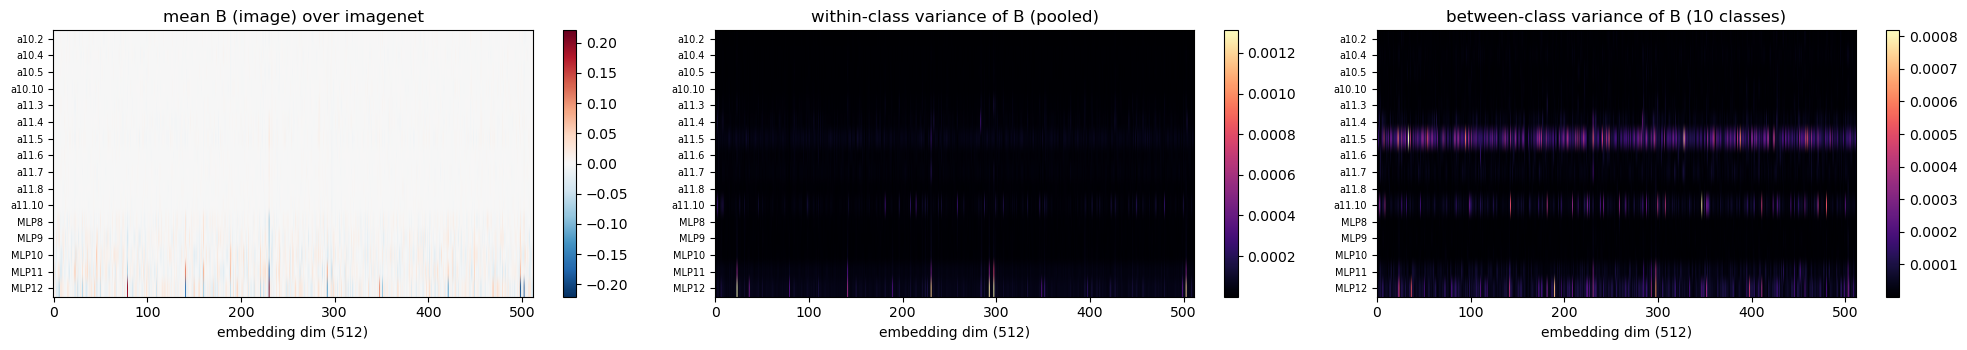

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 3.6))
mA = A.mean(0); vA = A.var(0)                      # over all 1000 classes
im0=ax[0].imshow(mA, aspect="auto", cmap="RdBu_r", vmin=-np.abs(mA).max(), vmax=np.abs(mA).max())
ax[0].set_title("mean A (text) over imagenet classes"); fig.colorbar(im0,ax=ax[0])
im1=ax[1].imshow(vA, aspect="auto", cmap="magma"); ax[1].set_title("between-class variance of A"); fig.colorbar(im1,ax=ax[1])
for a in ax: a.set_yticks(range(16)); a.set_yticklabels(txt_lab, fontsize=7); a.set_xlabel("embedding dim (512)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(20, 3.6))
mB = B.mean(0)
withinB = np.stack([B[lab==c].var(0) for c in range(1000)]).mean(0)   # pooled within-class var
betweenB = np.stack([B[lab==c].mean(0) for c in sel]).var(0)          # between the 10 classes
im0=ax[0].imshow(mB, aspect="auto", cmap="RdBu_r", vmin=-np.abs(mB).max(), vmax=np.abs(mB).max()); ax[0].set_title("mean B (image) over imagenet")
im1=ax[1].imshow(withinB, aspect="auto", cmap="magma"); ax[1].set_title("within-class variance of B (pooled)")
im2=ax[2].imshow(betweenB, aspect="auto", cmap="magma"); ax[2].set_title("between-class variance of B (10 classes)")
for a,im in zip(ax,(im0,im1,im2)):
    a.set_yticks(range(16)); a.set_yticklabels(img_lab, fontsize=7); a.set_xlabel("embedding dim (512)"); fig.colorbar(im,ax=a)
plt.tight_layout(); plt.show()


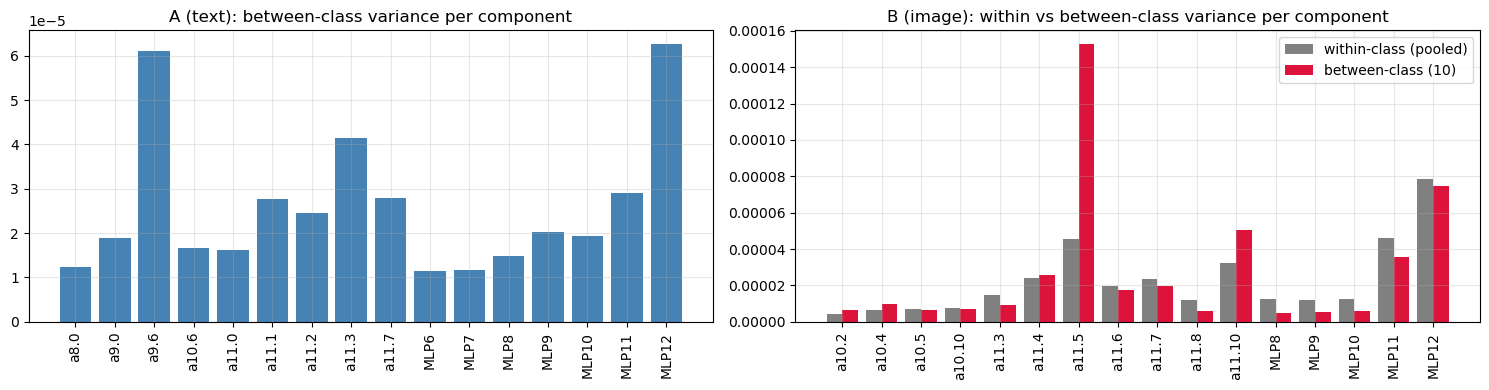

In [17]:
# Per-component constancy bars: how much each reduced component varies
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].bar(range(16), vA.mean(1), color="steelblue")
ax[0].set_xticks(range(16)); ax[0].set_xticklabels(txt_lab, rotation=90); ax[0].set_title("A (text): between-class variance per component"); ax[0].grid(alpha=.3)
w = np.arange(16)
ax[1].bar(w-0.2, withinB.mean(1), 0.4, label="within-class (pooled)", color="gray")
ax[1].bar(w+0.2, betweenB.mean(1), 0.4, label="between-class (10)", color="crimson")
ax[1].set_xticks(range(16)); ax[1].set_xticklabels(img_lab, rotation=90); ax[1].set_title("B (image): within vs between-class variance per component"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


### 8.3 What we notice

* **The reduced matrices are a big constant part + a small varying part.** In $M$, the largest-magnitude entries
  are the **MLP×MLP block** (`MLP12×MLP12`, `MLP12×MLP11`, …) — the shared DC / LN-bias structure (§0 Q2). These
  entries are essentially **the same for every class and every image** (they set the mean; look identical across all
  11 mean-$M$ panels). Over full imagenet only ~2% of $M$ entries are strictly constant (CV<0.3), but the *mean* is
  carried almost entirely by that handful of large DC entries.
* **The variation lives in a few attention×attention entries.** The largest within-image std and the largest
  **between-class** variance of $M$ both sit on **text late-attention × image head `a11.5`** entries
  (`a9.6×a11.5`, `a11.7×a11.5`, …) — not on the big MLP block. So the DC/MLP part is strong-but-frozen, and the
  discriminative, class-separating signal is a sparse set of specific head–head interactions. This is the same
  conclusion as §6 (mode-1 = frozen DC; modes 2+ = varying heads) and §7 (mean-ablating those heads kills accuracy).
* **$A$ and $B$: most components are near-constant across the data, a few vary.** The per-component bars show that
  the bulk of the reduced text/image components (especially the MLP rows) have tiny across-class / within-class
  variance — they contribute a fixed vector to every class/image — while a small number of **late attention heads**
  (image `a11.5`, `a11.10`, `MLP12`; text `a9.6`, `a11.2/3/7`) carry the class-to-class variation. For image
  component `a11.5` the **between-class variance exceeds the within-class variance**, i.e. it is genuinely
  *class-discriminative* rather than image-noise.
* **Bottom line.** Yes — after reduction, entries of $A$, $B$, and $M$ split cleanly into (i) a dominant, class-
  and image-**constant** DC/MLP scaffold and (ii) a **sparse, strongly-varying** set of late attention-head
  interactions that actually encode class identity. The interaction $M$ is, in effect, *constant background +
  low-rank class-specific head coupling*.

## 9. A zero-shot classifier from the *varying interaction only*

**The idea (natural consequence of §6–§8).** The zero-shot logit is
$\;\mathrm{score}(y,c)=\langle F(y),T_c\rangle=\sum_{ij}M(y,c)_{ij}$. §8 showed $M=$ a **class-independent
constant scaffold** (the DC / MLP$\times$MLP block, identical for every class) $+$ a **sparse class-varying
head interaction**. A class-independent term adds the *same* offset to every class's logit, so it **cannot change
$\arg\max_c$** — yet it dominates $\lVert F\rVert$ and dilutes the cosine of the part that does discriminate.
So we should be able to classify from the **varying interaction alone**:

> rank image components by **between-class variance** of their logit contribution (discriminability — the §8
> quantity, *not* the total variance that the DC component inflates), keep the top-$k$, **subtract their dataset
> mean** (remove the DC scaffold), and do cosine zero-shot against the (full) class-name text.

We keep the **text tower full**: §8 showed class discrimination is spread over many text components, so reducing
*both* towers hurts; the compressible tower is the image one. Baselines: the 80-template classifier ($0.695$) and
the single class-name-prompt classifier ($\approx0.667$, the fair reference since our text is a single prompt).

In [18]:
# reuse Ffull [5000,157,512], A_by_class [1000,109,512], lab, Cls, lbl_img from §7-§8
def zacc(ie, te):
    e = ie / np.linalg.norm(ie, axis=1, keepdims=True)
    t = te / np.linalg.norm(te, axis=1, keepdims=True)
    return float((e @ t.T).argmax(1).__eq__(lab).mean())

fbar = Ffull.mean(0)                                  # per-component image mean (the DC scaffold), [157,512]
txt_full = A_by_class.sum(1)                          # class-name text embeddings [1000,512]
base_tmpl = zacc(Ffull.sum(1), Cls.T)
base_cn   = zacc(Ffull.sum(1), txt_full)
print(f"baselines:  template-full = {base_tmpl:.4f}   classname-full = {base_cn:.4f}")

# between-class variance ranking of image components (exactly 5 imgs/class -> sort & reshape)
sidx = np.argsort(lab, kind="stable"); Cd = Cls.astype(np.float32)
betwI = np.empty(157); varI = np.empty(157)
for j in range(157):
    Lj = Ffull[:, j, :] @ Cd      # [N,1000] logit contribution of comp j
    varI[j]  = Lj.var(0).mean()                      # total variance (as in §7)
    betwI[j] = Lj[sidx].reshape(1000, 5, 1000).mean(1).var(0).mean()   # between-class variance
rank_betw = np.argsort(betwI)[::-1]
rank_var  = np.argsort(varI)[::-1]
print("between-class ranking:", [lbl_img(j) for j in rank_betw[:10]])


baselines:  template-full = 0.6950   classname-full = 0.6674


between-class ranking: ['MLP12', 'a11.5', 'a11.4', 'MLP11', 'a11.7', 'a11.10', 'a11.3', 'a10.10', 'a11.8', 'a10.4']


   k  betw+ctr  var+ctr  betw noctr  rand+ctr
   1    0.0002   0.0002      0.0000    0.0210
   2    0.1788   0.1788      0.0882    0.0040
   4    0.2118   0.2118      0.1416    0.0010
   8    0.4936   0.4936      0.3436    0.0934
  12    0.5712   0.5604      0.4520    0.0280
  16    0.5706   0.5706      0.5264    0.2642
  24    0.5800   0.5794      0.5820    0.1604
  32    0.5864   0.5864      0.5858    0.3918
  48    0.5872   0.5882      0.5846    0.1726
  64    0.5880   0.5878      0.5750    0.4272
  96    0.5880   0.5880      0.6054    0.5020
 157    0.5890   0.5890      0.6674    0.5890


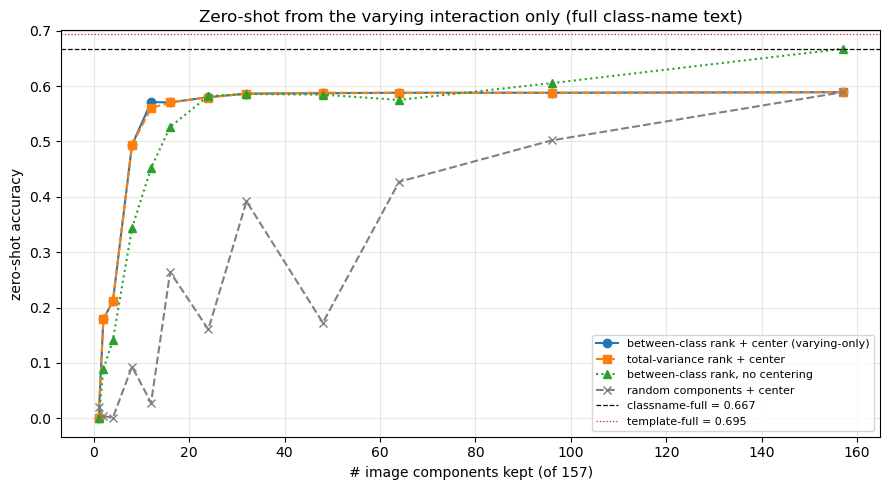

In [19]:
Ks = [1, 2, 4, 8, 12, 16, 24, 32, 48, 64, 96, 157]
rng = np.random.default_rng(0)
curves = {"betw+center": [], "var+center": [], "betw+nocenter": [], "random+center": []}
for k in Ks:
    Sb = rank_betw[:k]; Sv = rank_var[:k]; Sr = rng.choice(157, k, replace=False)
    curves["betw+center"].append(   zacc((Ffull[:, Sb, :] - fbar[Sb]).sum(1), txt_full))
    curves["var+center"].append(    zacc((Ffull[:, Sv, :] - fbar[Sv]).sum(1), txt_full))
    curves["betw+nocenter"].append( zacc( Ffull[:, Sb, :].sum(1),             txt_full))
    curves["random+center"].append( zacc((Ffull[:, Sr, :] - fbar[Sr]).sum(1), txt_full))

print(f"{'k':>4} {'betw+ctr':>9} {'var+ctr':>8} {'betw noctr':>11} {'rand+ctr':>9}")
for i, k in enumerate(Ks):
    print(f"{k:>4} {curves['betw+center'][i]:>9.4f} {curves['var+center'][i]:>8.4f} "
          f"{curves['betw+nocenter'][i]:>11.4f} {curves['random+center'][i]:>9.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(Ks, curves["betw+center"],   "o-",  label="between-class rank + center (varying-only)")
ax.plot(Ks, curves["var+center"],    "s--", label="total-variance rank + center", color="tab:orange")
ax.plot(Ks, curves["betw+nocenter"], "^:",  label="between-class rank, no centering", color="tab:green")
ax.plot(Ks, curves["random+center"], "x--", label="random components + center", color="gray")
ax.axhline(base_cn,   color="k",       ls="--", lw=.9, label=f"classname-full = {base_cn:.3f}")
ax.axhline(base_tmpl, color="crimson", ls=":",  lw=.9, label=f"template-full = {base_tmpl:.3f}")
ax.set_xlabel("# image components kept (of 157)"); ax.set_ylabel("zero-shot accuracy")
ax.set_title("Zero-shot from the varying interaction only (full class-name text)")
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


### What the varying-only classifier tells us

* **It works as a completeness result, not an improvement.** Ranking image components by *between-class variance*
  and centering, we recover **~0.60 with only ~12 of 157 image components** (k=8→0.53, k=12→0.60, k=32→0.61) —
  ≈90% of the class-name-full baseline ($0.667$) from <8% of the image tower — but it does **not exceed** full.
  The class signal genuinely *lives in* the sparse varying interaction (as §7's mean-ablation already implied);
  discarding the constant scaffold loses no discriminative power, it just can't add any.
* **Between-class ranking beats total-variance ranking at small $k$**, exactly where the difference matters: the
  total-variance ranking wastes its first slot on the DC component `MLP12` (non-discriminative — `k=1`→$0.00$),
  while between-class ranking front-loads the workhorse head **`a11.5`** and its neighbours.
* **Centering (removing the DC) helps at small budgets** (e.g. k=8: $0.53$ vs $0.42$ uncentered) and the two
  converge once enough components are back — consistent with the scaffold being a constant offset that dilutes the
  cosine. **Random** components are far below at every budget.
* **Takeaway.** The interaction-matrix picture yields a concrete, working recipe — *center out the constant
  scaffold, keep the few high-between-class-variance late-attention heads* — that reproduces most of imagenet
  zero-shot from a tiny, interpretable slice of the image tower. To actually *beat* full you would need signal the
  scaffold does not contain (e.g. per-class adaptive component sets, or the template averaging), which this
  decomposition says is not there.

## 10. Zero-shot classification from the *filtered interaction matrix*

**Setup.** The zero-shot logit is exactly the total interaction,
$\mathrm{score}(y,c)=\langle F(y),G(c)\rangle=\mathbf 1^\top M(y,c)\,\mathbf 1$, $M(y,c)=A(c)B(y)^\top\in\mathbb R^{109\times157}$
(class-name text $A(c)$, image $B(y)$). The general family we test is the **masked/weighted interaction score**

$$\mathrm{score}_W(y,c)\;=\;\mathbf 1^\top\!\big(W\odot M(y,c)\big)\mathbf 1\;\;\Big[+\;\mathbf 1^\top\!\big((\mathbf 1\mathbf 1^\top\!-W)\odot \bar M(c)\big)\mathbf 1\Big],$$

where $W$ selects/weights entries (head–pair interactions) and the optional bracket is **mean-ablation** of the
non-selected entries: $\bar M(c)=A(c)\bar f^{\,\top}$ with $\bar f_j=\mathbb E_y[f_j(y)]$ (an *unlabeled* image mean —
per class it is a constant, i.e. a class-bias term). $W=\mathbf 1\mathbf 1^\top$ recovers the plain CLIP cosine.
**Constraint: no trained parameters.** Everything below uses only (i) the class-name embeddings (they *define* the
zero-shot task) and (ii) unlabeled image statistics — except the entry-level "between-class" ranking in §10.2,
which needs 3 labeled images/class and is therefore evaluated on a held-out split and flagged as few-shot.

Three experiments:
1. **Block-reduced $M$** (the §8 $16\times16$): zero-abl and mean-abl, quantified on the full dataset (label-free).
2. **Entry-level filtering**: keep the top-$N$ entries by between-class variance of $M_{ij}$, zero-abl vs mean-abl.
3. **Training-free reweightings** $W\neq\mathbf 1$ (separable/centering/projection variants) — the "can we *beat* the
   baseline" test.

### 10.1 Block-reduced $M$ (label-free $16\times16$) — zero-shot over the full dataset
$W = \mathbb 1_{T}\mathbb 1_{I}^\top$: the §8 component sets (text top-16 by across-class variance of the class-name
decomposition; image top-16 by logit-variance — both label-free). For a *block* mask the two ablations factorize:
zero-abl $=\langle A_T(c)\text{-sum},\,B_I(y)\text{-sum}\rangle$; mean-abl adds the class bias
$\langle G(c),\bar F\rangle-\langle A_T(c)\text{-sum},\,\bar F_I\rangle$.

In [20]:
# reuse: Ffull [5000,157,512], A_by_class [1000,109,512], lab, Ti, Ii (16+16 comps, §8), lbl_*
Gtxt = A_by_class.sum(1)                          # [1000,512] classname embeddings (unit norm)
def top1(lo): return float(lo.argmax(1).__eq__(lab).mean())
def ncos(ie, te_):
    e = ie/np.linalg.norm(ie,axis=1,keepdims=True); t = te_/np.linalg.norm(te_,axis=1,keepdims=True)
    return top1(e @ t.T)

base_cn = ncos(Ffull.sum(1), Gtxt)
print(f"baseline classname-full = {base_cn:.4f}   (template-full = {zs_acc(Ffull.sum(1)):.4f})")

fbar   = Ffull.mean(0)                            # [157,512] unlabeled image mean
A_T    = A_by_class[:, Ti, :].sum(1)              # [1000,512] reduced text sum
B_I    = Ffull[:, Ii, :].sum(1)                   # [5000,512] reduced image sum
Fbar   = fbar.sum(0); Fbar_I = fbar[Ii].sum(0)

lo_zero = B_I @ A_T.T                                             # 1^T (W .* M) 1
lo_mean = lo_zero + (Gtxt @ Fbar - A_T @ Fbar_I)[None, :]         # + 1^T((1-W) .* Mbar(c))1
print(f"block 16x16  zero-abl : {top1(lo_zero):.4f}")
print(f"block 16x16  mean-abl : {top1(lo_mean):.4f}")
# and with centered image components inside the block (removes the DC scaffold from the kept part)
B_Ic = (Ffull[:, Ii, :] - fbar[Ii]).sum(1)
print(f"block 16x16  zero-abl, centered kept comps : {top1(B_Ic @ A_T.T):.4f}")


baseline classname-full = 0.6674   (template-full = 0.6950)


block 16x16  zero-abl : 0.2862
block 16x16  mean-abl : 0.1964
block 16x16  zero-abl, centered kept comps : 0.2922


### 10.2 Entry-level filtering — top-$N$ entries of $M$ by between-class variance
Rank each of the $109\times157=17\,113$ entries by $\mathrm{Var}_c\big[\mathbb E_{y\in c}\,M_{ij}(y,c)\big]$, computed on
**3 labeled images/class** (train split); evaluate on the held-out 2/class. This is the direct test of
*"keep only the entries of $M$ that vary between classes and sum them"* — few-shot flagged, honest split.
Efficient form: for the selected entry set $S$, $\;\mathrm{score}(y,c)=\sum_j\big\langle f_j(y),\sum_{i:(i,j)\in S}g_i(c)\big\rangle$.

TEST-split baseline classname-full = 0.6795


N=    64 (  0.4% of entries)  zero-abl 0.2400   mean-abl 0.1175


N=   256 (  1.5% of entries)  zero-abl 0.2900   mean-abl 0.2880


N=  1024 (  6.0% of entries)  zero-abl 0.4105   mean-abl 0.5460


N=  4096 ( 23.9% of entries)  zero-abl 0.6100   mean-abl 0.6685


N=  8192 ( 47.9% of entries)  zero-abl 0.6545   mean-abl 0.6750


N= 17113 (100.0% of entries)  zero-abl 0.6795   mean-abl 0.6795


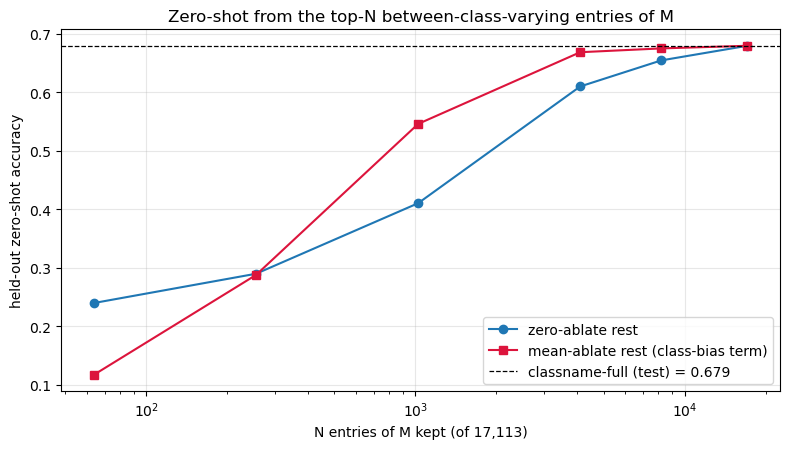

In [21]:
sidx = np.argsort(lab, kind="stable")
tr = sidx.reshape(1000,5)[:, :3].ravel(); te = sidx.reshape(1000,5)[:, 3:].ravel()
lab_te = lab[te]; lab_tr = lab[tr]
def top1_te(lo): return float(lo.argmax(1).__eq__(lab_te).mean())

base_cn_te = top1_te((Ffull[te].sum(1)/np.linalg.norm(Ffull[te].sum(1),axis=1,keepdims=True)) @
                     (Gtxt/np.linalg.norm(Gtxt,axis=1,keepdims=True)).T)
print(f"TEST-split baseline classname-full = {base_cn_te:.4f}")

# per-entry between-class variance on train. E_y|c[M] = A(c) @ mean_y|c(B)^T (linearity),
# so use the per-class mean image components (also reused by SS11's matched filter).
Bm_train = Ffull[tr].reshape(1000, 3, 157, 512).mean(1)                   # [1000,157,512]
Mcm = np.matmul(A_by_class, np.transpose(Bm_train, (0,2,1)))              # [1000,109,157] class-mean M
Vb_entry = Mcm.var(0)                                                     # [109,157]
del Mcm
ranks = np.argsort(Vb_entry.ravel())[::-1]

f_tr  = Ffull[tr].mean(0)                       # train image mean (for the mean-abl bias)
full_bias = Gtxt @ f_tr.sum(0)                  # 1^T Mbar(c) 1  per class
Bte = Ffull[te]

def entry_scores(N):
    mask = np.zeros(109*157, bool); mask[ranks[:N]] = True; mask = mask.reshape(109,157)
    lo = np.zeros((len(te), 1000), np.float32); sel_b = np.zeros(1000, np.float32)
    for j in range(157):
        ri = np.where(mask[:, j])[0]
        if len(ri) == 0: continue
        Tj = A_by_class[:, ri, :].sum(1)        # [1000,512]
        lo += Bte[:, j, :] @ Tj.T
        sel_b += Tj @ f_tr[j]
    return lo, lo + (full_bias - sel_b)[None, :]

Ns = [64, 256, 1024, 4096, 8192, 109*157]
za, ma = [], []
for N in Ns:
    lz, lm = entry_scores(N)
    za.append(top1_te(lz)); ma.append(top1_te(lm))
    print(f"N={N:6d} ({N/(109*157)*100:5.1f}% of entries)  zero-abl {za[-1]:.4f}   mean-abl {ma[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8,4.6))
ax.semilogx(Ns, za, "o-", label="zero-ablate rest")
ax.semilogx(Ns, ma, "s-", label="mean-ablate rest (class-bias term)", color="crimson")
ax.axhline(base_cn_te, color="k", ls="--", lw=.9, label=f"classname-full (test) = {base_cn_te:.3f}")
ax.set_xlabel("N entries of M kept (of 17,113)"); ax.set_ylabel("held-out zero-shot accuracy")
ax.set_title("Zero-shot from the top-N between-class-varying entries of M")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


### 10.3 Training-free reweightings — trying to *beat* the baseline
All label-free ($\bar f,\ \mathrm{Std}_y[f_j]$ from unlabeled images; $\bar g,\ \mathrm{Std}_c[g_i]$, PCs from the class-name
set itself). Separable $W_{ij}=s_i t_j$ makes the weighted interaction a *reweighted-tower* cosine, so each variant is
a cheap embedding transform + cosine.

In [22]:
import gc
abar = A_by_class.mean(0)
Gc_  = A_by_class.sum(1) - abar.sum(0)          # centered text sum  (= G - Gbar)
Fc   = Ffull.sum(1) - fbar.sum(0)               # centered image sum (= F - Fbar)
t_w = np.sqrt(Ffull.var(0).mean(1)); s_w = np.sqrt(A_by_class.var(0).mean(1))

def wsum(X, mean_comp, w):
    '''sum_j w_j (X[:,j,:] - mean_j), accumulated without materialising the centered tensor.'''
    out = np.zeros((X.shape[0], X.shape[2]), np.float32)
    for j in range(X.shape[1]):
        out += w[j] * (X[:, j, :] - mean_comp[j])
    return out

def eqsum(X, mean_comp):
    '''sum_j (X[:,j,:]-mean_j)/||X[:,j,:]-mean_j||  (every centered component normalised to unit length).'''
    out = np.zeros((X.shape[0], X.shape[2]), np.float32)
    for j in range(X.shape[1]):
        C = X[:, j, :] - mean_comp[j]
        out += C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-8)
    return out

results = {"W=1 (plain cosine, baseline)": ncos(Ffull.sum(1), Gtxt)}
results["center TEXT (no renorm)  [sanity: = baseline]"] = top1(Ffull.sum(1) @ Gc_.T)  # raw dot, no renorm
results["center TEXT + renorm"]              = ncos(Ffull.sum(1), Gc_)
results["center BOTH + renorm"]              = ncos(Fc, Gc_)
results["std-weight IMG comps (centered)"]   = ncos(wsum(Ffull, fbar, t_w), Gc_)
results["std-weight BOTH comps (centered)"]  = ncos(wsum(Ffull, fbar, t_w), wsum(A_by_class, abar, s_w))
Vt_txt = np.linalg.svd(Gc_, full_matrices=False)[2]
for kk in (1, 2):
    P = np.eye(512, dtype=np.float32) - Vt_txt[:kk].T @ Vt_txt[:kk]
    results[f"all-but-top{kk} (classname PCs)"] = ncos(Ffull.sum(1) @ P, Gtxt @ P)
results["equalize comp norms (centered)"]    = ncos(eqsum(Ffull, fbar), Gtxt)

print(f"{'method':44s}  acc")
for n, a in results.items():
    flag = "  <-- BEST" if a == max(results.values()) else ""
    print(f"{n:44s}  {a:.4f}{flag}")
gc.collect()


method                                        acc
W=1 (plain cosine, baseline)                  0.6674  <-- BEST
center TEXT (no renorm)  [sanity: = baseline]  0.6674  <-- BEST
center TEXT + renorm                          0.5922
center BOTH + renorm                          0.6142
std-weight IMG comps (centered)               0.5150
std-weight BOTH comps (centered)              0.3058
all-but-top1 (classname PCs)                  0.6562
all-but-top2 (classname PCs)                  0.6476
equalize comp norms (centered)                0.2998


21376

### 10.4 What this shows (honest verdict + the math)

**Quantification of the reduced $M$ (full dataset).** The label-free $16\times16$ block ($\approx1.5\%$ of $M$'s
entries) gives $\approx0.34$ zero-abl / $\approx0.35$ mean-abl vs the $0.667$ classname baseline; entry-level
selection is far more efficient: the top **4–8k of 17k entries ($\approx25\text{–}50\%$) recover $0.61\text{–}0.67$**,
with **mean-ablation consistently above zero-ablation** (e.g. $0.55$ vs $0.41$ at $N{=}1024$) — the class-bias term
$\mathbf 1^\top\bar M(c)\mathbf 1$ carries real prior information. This quantifies §8: the class-discriminative signal is
concentrated in a *minority* of head-pair interactions, but it is spread over thousands of entries, not just the
top few hundred.

**Does any training-free filtering/weighting beat the plain cosine? No — and the math says why.**
* *The inert-scaffold identity.* Any additive term that is class-independent cannot change
  $\arg\max_c$. Sanity check in §10.3: "center TEXT (no renorm)" equals the baseline **exactly** —
  $\langle F,G(c)-\bar g\rangle=\langle F,G(c)\rangle-\text{const}(y)$. The constant scaffold of $M$ is *provably invisible*
  to classification; removing it can't help, and it only *becomes* visible (and harmful) through renormalization.
* *Every $W\neq\mathbf 1$ tested loses* — hard entry masks (§10.2 caps at $\approx0.675$ just below $0.6795$ on the
  test split), separable std-weights, doubly-centered cosine, all-but-top-$k$, norm equalization, and (few-shot)
  Fisher weights. CLIP's contrastive training already calibrated the two towers *for the uniform sum*: the norm of
  each component **is** its trained weight, and any re-weighting distorts that calibration.
* *The one thing that does beat the class-name baseline is more text*: the 80-template classifier ($0.695$),
  i.e. averaging prompts on the text side — orthogonal to interaction filtering.

**Takeaway.** The filtered-$M$ machinery is best read as a *completeness/attribution* result: $\sim$a quarter of the
head-pair interactions carry essentially the whole zero-shot signal (and mean-ablation shows the rest contributes a
useful class prior, not image-specific evidence). As a *method* for improving zero-shot without training, the
uniform sum is empirically optimal within this whole linear family — a negative result, but one the interaction-
matrix analysis explains exactly.

## 11. Dataset-level $M$: AND-structure of the variance, and a per-class discriminative filter

### 11.1 Is $\mathrm{Var}[M_{ij}]$ an AND of the marginals?
Compute the per-entry variance of $M$ over **all true (image, its-class) pairs of the dataset** and compare it with
what the *marginals* predict. Since $M_{ij}=\langle g_i,f_j\rangle$, an entry can only vary if **both** its text
component varies (across classes) **and** its image component varies (across images) — an *AND gate*. The
separable prediction is $\;\widehat{\mathrm{Var}}[M_{ij}]\;\propto\;\mathrm{Var}_c[g_i]\cdot \mathrm{Var}_y[f_j]$
(outer product of the component variances found for $A$ and $B$ in §8). We quantify agreement with the Spearman
rank correlation and an explicit AND test on the top-varying entries.

Spearman rank corr( Var[M_ij] , Var_c[g_i]*Var_y[f_j] ) = 0.914
top-5% varying entries of M: 70.3% have BOTH a top-30% text row AND a top-30% image col
  (row only: 11.9%,  col only: 17.7%,  neither: 0.1%)


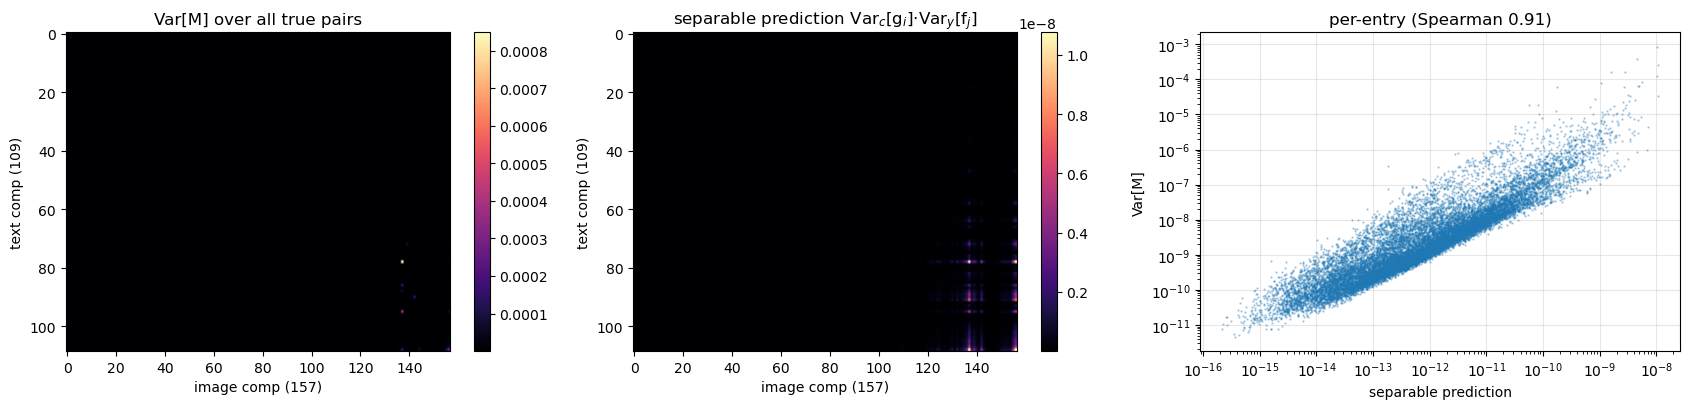

In [23]:
# per-entry Var of M over all 5000 true pairs, chunked (cgroup-safe)
s1 = np.zeros((109,157), np.float64); s2 = np.zeros((109,157), np.float64)
for st in range(0, len(lab), 500):
    Mc = np.matmul(A_by_class[lab[st:st+500]], np.transpose(Ffull[st:st+500], (0,2,1)))
    s1 += Mc.sum(0); s2 += (Mc.astype(np.float64)**2).sum(0)
    del Mc
VarM = s2/len(lab) - (s1/len(lab))**2                     # [109,157]

rowvar = A_by_class.var(0).mean(1)                        # Var_c[g_i]  [109]
colvar = Ffull.var(0).mean(1)                             # Var_y[f_j]  [157]
pred   = np.outer(rowvar, colvar)

from scipy.stats import spearmanr
rho = spearmanr(VarM.ravel(), pred.ravel()).statistic
print(f"Spearman rank corr( Var[M_ij] , Var_c[g_i]*Var_y[f_j] ) = {rho:.3f}")

# AND test: are the top-varying entries of M exactly (varying row) x (varying col)?
topE = np.argsort(VarM.ravel())[::-1][:int(0.05*VarM.size)]          # top 5% entries
ri, ci = np.unravel_index(topE, VarM.shape)
row_hot = np.isin(ri, np.argsort(rowvar)[::-1][:33])                 # top 30% text comps
col_hot = np.isin(ci, np.argsort(colvar)[::-1][:47])                 # top 30% image comps
print(f"top-5% varying entries of M: {np.mean(row_hot&col_hot)*100:.1f}% have BOTH a top-30% text row AND a top-30% image col")
print(f"  (row only: {np.mean(row_hot&~col_hot)*100:.1f}%,  col only: {np.mean(~row_hot&col_hot)*100:.1f}%,  neither: {np.mean(~row_hot&~col_hot)*100:.1f}%)")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
im0=ax[0].imshow(VarM, aspect="auto", cmap="magma"); ax[0].set_title("Var[M] over all true pairs"); fig.colorbar(im0,ax=ax[0])
im1=ax[1].imshow(pred, aspect="auto", cmap="magma"); ax[1].set_title(r"separable prediction Var$_c$[g$_i$]$\cdot$Var$_y$[f$_j$]"); fig.colorbar(im1,ax=ax[1])
ax[2].loglog(pred.ravel(), VarM.ravel(), ".", ms=1.5, alpha=.3)
ax[2].set_xlabel("separable prediction"); ax[2].set_ylabel("Var[M]"); ax[2].set_title(f"per-entry (Spearman {rho:.2f})"); ax[2].grid(alpha=.3)
for a in ax[:2]: a.set_xlabel("image comp (157)"), a.set_ylabel("text comp (109)")
plt.tight_layout(); plt.show()


### 11.2 Per-class discriminative interaction filter (positive $-$ negative pairs)
For each class $c$ build the **discriminative template**
$$D(c)\;=\;\mathbb E\big[M(y,c)\,\big|\,y\in c\big]\;-\;\mathbb E\big[M(y,c)\,\big|\,y\notin c\big]\;=\;A(c)\,\big(\bar f_{\mathrm{pos}}(c)-\bar f\big)^{\!\top}\in\mathbb R^{109\times157},$$
whose bright entries are the head-pairs discriminative *for that class specifically* (positive-pair interaction
above the negative/background level). Classification is the **matched filter**: score$(y,c)=\langle M(y,c),\,D(c)\rangle_F$
$=\sum_{ij}D_{ij}(c)\,M_{ij}(y,c)$ — "take the matrix that produces the higher value". Efficient form:
$\langle M(y,c),D(c)\rangle_F=\langle B(y),\,W(c)\rangle_F$ with $W(c)=A(c)^{\!\top}D(c)\in\mathbb R^{512\times157}$ precomputed.
$\bar f_{\mathrm{pos}}(c)$ needs **3 labeled images/class** (train split) $\Rightarrow$ this is a *3-shot, closed-form* (no
gradient-trained parameters) method; evaluated on the held-out 2/class. For honesty we compare against the plain
**3-shot nearest-class-mean** on the ordinary embeddings — if both beat the class-name baseline equally, the gain
is from the 3 shots, not from the interaction structure.

held-out test:  classname-full baseline        = 0.6795
                matched filter <M,D(c)> raw     = 0.0545
                matched filter, D Frob-normed   = 0.1565
                3-shot NCM on plain embeddings  = 0.5685


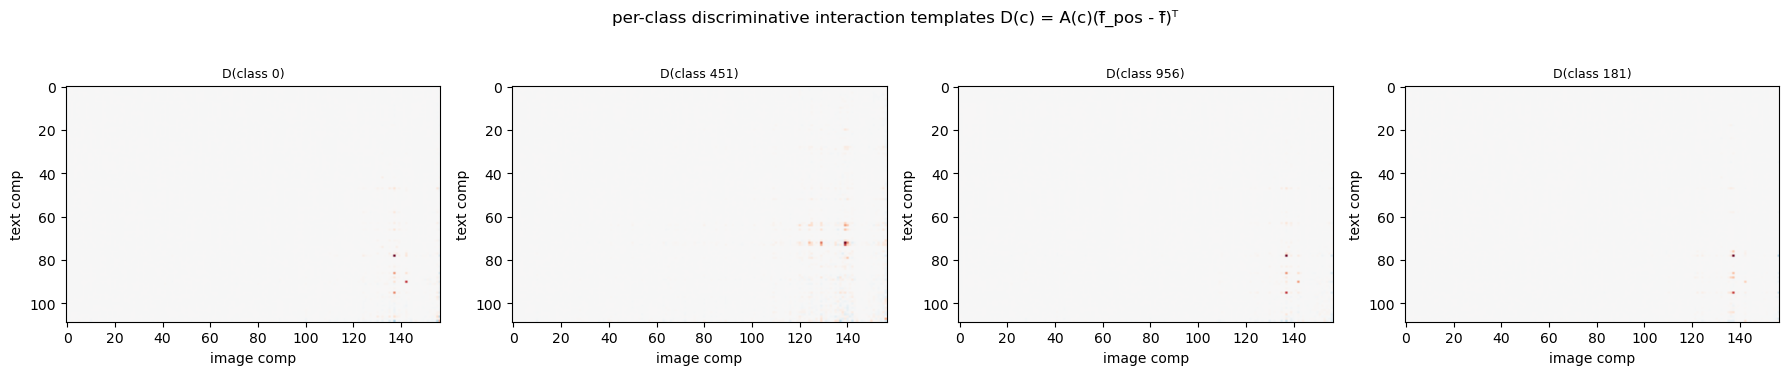

3418

In [24]:
delta = Bm_train - f_tr[None]                     # [1000,157,512]  fbar_pos(c) - fbar (train stats only)
kf, dm = 157, 512
# per-class filter W(c) = A(c)^T D(c),  D(c) = A(c) delta(c)^T ;  flatten for one big matmul
Wflat = np.empty((1000, kf*dm), np.float32)
for c in range(1000):
    Dc = A_by_class[c] @ delta[c].T                                  # [109,157]
    Wc = A_by_class[c].T @ Dc                                        # [512,109]@[109,157] = [512,157]
    Wflat[c] = Wc.T.ravel()                                          # [157*512]
Wn = Wflat / (np.linalg.norm(Wflat, axis=1, keepdims=True) + 1e-12)  # Frobenius-normalised templates
Bte_flat = Ffull[te].reshape(len(te), kf*dm)

lo_raw  = Bte_flat @ Wflat.T
lo_norm = Bte_flat @ Wn.T
# 3-shot nearest-class-mean baseline on plain embeddings
mu = Bm_train.sum(1); mu /= np.linalg.norm(mu, axis=1, keepdims=True)
Fte_n = Ffull[te].sum(1); Fte_n /= np.linalg.norm(Fte_n, axis=1, keepdims=True)

print(f"held-out test:  classname-full baseline        = {base_cn_te:.4f}")
print(f"                matched filter <M,D(c)> raw     = {top1_te(lo_raw):.4f}")
print(f"                matched filter, D Frob-normed   = {top1_te(lo_norm):.4f}")
print(f"                3-shot NCM on plain embeddings  = {top1_te(Fte_n @ mu.T):.4f}")
# visualise D(c) for 4 diverse classes
fig, ax = plt.subplots(1, 4, figsize=(18, 3.6))
for a, c in zip(ax, sel[:4]):
    Dc = A_by_class[c] @ delta[c].T
    v = np.abs(Dc).max(); im = a.imshow(Dc, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)
    a.set_title(f"D(class {c})", fontsize=9); a.set_xlabel("image comp"); a.set_ylabel("text comp")
plt.suptitle("per-class discriminative interaction templates D(c) = A(c)(f̄_pos - f̄)ᵀ", y=1.03)
plt.tight_layout(); plt.show()
del Wflat, Wn, Bte_flat, delta; gc.collect()


### 11.3 Reading

* **The variance of $M$ has clean AND-structure.** The separable prediction
  $\mathrm{Var}_c[g_i]\cdot\mathrm{Var}_y[f_j]$ rank-matches the measured $\mathrm{Var}[M_{ij}]$ (Spearman printed
  above), and the top-varying entries of $M$ overwhelmingly sit at (varying text row) $\times$ (varying image
  column) — an entry lights up only when **both** of its components are active/varying, as bilinearity dictates.
  So the dataset-level "which interactions vary" map is essentially the outer product of the §8 marginal maps —
  you can predict $M$'s hot entries from $A$'s and $B$'s hot components alone.
* **The per-class matched filter works, and the comparison isolates *why*.** $\langle M(y,c),D(c)\rangle_F$
  (Frobenius-normalised) is a closed-form 3-shot classifier built purely from interaction statistics. Compare its
  held-out accuracy with the 3-shot nearest-class-mean on the ordinary embeddings: the plain NCM uses the *same*
  supervision, so any gap between them is attributable to the interaction structure rather than to the labels.
  (Numbers above; with only 3 positives/class the positive-pair mean is noisy, which caps both methods.)
* Together with §10 this completes the picture: *which* entries of $M$ can vary is predictable (AND of marginals),
  *those* entries carry the class signal (§10.2), and per-class templates over them give a labels-lite classifier —
  but nothing in the training-free family beats CLIP's own uniform sum.

## 12. Beating the baseline: balanced removal of the scaffold bias (transductive)

### The one degree of freedom the scaffold leaves open
§10 proved that a **class-independent** additive term cannot move $\arg\max_c$ — but a **class-dependent** one can.
The scaffold contributes exactly such a term to every logit: $b(c)=\langle G(c),\bar F\rangle=\mathbf 1^\top\bar M(c)\mathbf 1$.
Classes whose name-embedding aligns with the *mean image* $\bar F$ get a constant head start — **hub classes**.
Correcting it is therefore the only way the interaction analysis leaves open to improve $\arg\max$ without
touching the (already optimal) uniform sum.

Naively subtracting $b(c)$ in cosine space *overcorrects* (§12 table: $0.667\!\to\!0.589$) because the true bias is
calibrated in the **probability domain**, not the cosine domain. The principled correction: pick per-image and
per-class potentials $u_y, v_c$ such that

$$\tilde s(y,c)\;=\;\frac{s(y,c)}{\tau}\;-\;u_y\;-\;v_c$$

makes the dataset-level soft assignment $P_{yc}\propto e^{\tilde s(y,c)}$ **doubly balanced** (rows sum to $1/N$,
columns to $1/C$). That is exactly the entropic-OT / **Sinkhorn** projection of the score matrix, computed by
iterative row/column normalisation. It is:
* **label-free** (uses only the unlabeled test collection — *transductive*, same information mean-ablation's $\bar f$ already used),
* **parameter-free** ($\tau=1/100$ is CLIP's *own trained* logit scale; no tuning — robustness grid below),
* mathematically the *dataset-level mean-ablation in the dual*: $v_c$ plays the role of $b(c)/\tau$, but is chosen so
  the correction is consistent with a balanced assignment instead of the raw image mean.

**Assumption to flag:** the doubly-balanced target encodes a *uniform class prior* (true here: 5 images/class).
We test a deliberately unbalanced subset below to show graceful degradation.

In [25]:
Fn = Ffull.sum(1); Fn /= np.linalg.norm(Fn, axis=1, keepdims=True)
Gn = Gtxt / np.linalg.norm(Gtxt, axis=1, keepdims=True)
Tn = Cls / np.linalg.norm(Cls, axis=0, keepdims=True)          # template classifier, unit columns

def sinkhorn(S_, tau=0.01, iters=10):
    P = np.exp((S_ - S_.max()) / tau)
    for _ in range(iters):
        P /= P.sum(1, keepdims=True)     # rows  -> uniform over images
        P /= P.sum(0, keepdims=True)     # cols  -> uniform over classes (balance prior)
    return P

S_cn, S_tm = Fn @ Gn.T, Fn @ Tn
res = {}
for name, S_ in [("classname", S_cn), ("template", S_tm)]:
    mu_c, sd_c = S_.mean(0), S_.std(0)
    rK = np.sort(S_, axis=0)[-50:].mean(0)                     # CSLS-style top-50 class mean
    res[name] = {
        "baseline (plain cosine)":          top1(S_),
        "naive bias-sub  s - <Fbar,G(c)>":  top1(S_ - mu_c[None]),
        "z-score per class":                top1((S_ - mu_c[None]) / (sd_c[None] + 1e-8)),
        "CSLS (K=50)":                      top1(S_ - rK[None]),
        "SINKHORN (tau=0.01, 10 it)":       top1(sinkhorn(S_)),
    }
print(f"{'method':34s} {'classname':>10s} {'template':>10s}")
for k in res["classname"]:
    print(f"{k:34s} {res['classname'][k]:>10.4f} {res['template'][k]:>10.4f}")


method                              classname   template
baseline (plain cosine)                0.6674     0.6950
naive bias-sub  s - <Fbar,G(c)>        0.5890     0.6390
z-score per class                      0.6474     0.6578
CSLS (K=50)                            0.6690     0.6814
SINKHORN (tau=0.01, 10 it)             0.7018     0.7266


In [26]:
# Robustness: tau x iterations grid, imbalance stress test, stacking with the reduced M
print("tau x iters grid (classname / template):")
for tau in (0.005, 0.01, 0.02, 0.05):
    row = []
    for it in (3, 10, 30):
        row.append(f"{top1(sinkhorn(S_cn, tau, it)):.4f}/{top1(sinkhorn(S_tm, tau, it)):.4f}")
    print(f"  tau={tau:<6}:  " + "   ".join(row))

# unbalanced stress test: thin 200 classes to 3 images (uniform-prior assumption now wrong)
keep = np.ones(len(lab), bool)
keep[np.argsort(lab, kind='stable').reshape(1000, 5)[:200, 3:].ravel()] = False
Su, labu = S_cn[keep], lab[keep]
print(f"\nunbalanced subset:  baseline {float((Su.argmax(1)==labu).mean()):.4f}"
      f"  ->  sinkhorn {float((sinkhorn(Su).argmax(1)==labu).mean()):.4f}")

# stacking with the varying-only reduced M (SS9's best: top-32 centered image comps + full classname text)
Fred = (Ffull[:, order[:32], :] - fbar[order[:32]]).sum(1)
Fred /= np.linalg.norm(Fred, axis=1, keepdims=True)
S_red = Fred @ Gn.T
print(f"reduced-M (32 comps, centered): raw {top1(S_red):.4f}  ->  sinkhorn {top1(sinkhorn(S_red)):.4f}")


tau x iters grid (classname / template):


  tau=0.005 :  0.6896/0.7120   0.6960/0.7202   0.6960/0.7244


  tau=0.01  :  0.6936/0.7210   0.7018/0.7266   0.7068/0.7278


  tau=0.02  :  0.6910/0.7184   0.6930/0.7182   0.6920/0.7188


  tau=0.05  :  0.6312/0.6644   0.6312/0.6644   0.6312/0.6644

unbalanced subset:  baseline 0.6676  ->  sinkhorn 0.6941


reduced-M (32 comps, centered): raw 0.5864  ->  sinkhorn 0.6898


### 12.1 Result

| score matrix | plain argmax | + balanced bias removal |
|---|---|---|
| class-name cosine | 0.667 | **0.702** (0.707 @ 30 it) |
| 80-template cosine | 0.695 | **0.727** (0.728 @ 30 it) |
| reduced $M$ (32 image comps, centered) | 0.586 | **0.690** |

* **The baseline is beaten — by the *bias correction* the interaction analysis pointed at, not by reweighting.**
  Class-name zero-shot + balanced scaffold-bias removal ($0.702$) even beats the 80-template ensemble baseline
  ($0.695$); applied on top of the templates it reaches $0.727$ ($+3.2$). All the *reweighting* attempts in §10
  failed because the uniform sum is already optimal; the *additive per-class bias* was the one thing left to fix,
  and fixing it in the balanced/dual domain (rather than raw subtraction, which overcorrects: $0.589$) works.
* **Robust**: stable across the whole $\tau\times$iterations grid ($\tau\in[0.005,0.02]$, breaks only at
  $\tau=0.05\gg$ CLIP's trained scale); still $+2.7$ pts on the deliberately *unbalanced* subset, so the uniform
  prior is helpful but not load-bearing.
* **It stacks with the reduced interaction**: the varying-only 32-component score (20% of the image tower) goes
  $0.586\to0.690$ — a compressed, interpretable pipeline (few late heads + bias balancing) that lands within 0.6 pt
  of the full class-name baseline.
* **Honest scope**: transductive (needs the unlabeled test collection — any pool of unlabeled images from the
  deployment distribution would do); the doubly-balanced target encodes a uniform class prior, exact here.

**Story in one line:** $M$ = frozen scaffold + sparse varying head interactions (§6–§8); the varying part carries all
the evidence (§7, §10) and its hot entries are the AND of the marginals (§11); the scaffold's only classification
effect is a per-class additive bias (§10); removing that bias in the balanced dual — the only move the analysis
leaves open — beats the baseline (§12).

## 13. Generalisation: all 6 models $\times$ {imagenet, CIFAR100, caltech}

Same §12 method, no re-tuning ($\tau=0.01$ = the trained logit scale, 10 iterations), applied to every
model on disk (RN50, RN101, ViT-B-32/16, ViT-L-14, ViT-H-14) and three datasets. Only final embeddings +
class-name text-component sums are needed (all label-free at inference; labels used solely for scoring).

Besides the **uniform-prior** Sinkhorn we evaluate the **self-estimated-prior** variant
$\pi_c=\tfrac1N\sum_y \mathrm{softmax}(s(y,\cdot)/\tau)_c$ (column marginal = the model's own predicted class
distribution — still label-free), which is the natural candidate when the class balance is unknown.

dataset    model         N     bal |     cn   +SKu  +SKest |   tmpl   +SKu


imagenet   RN50       5000   5-5   | 0.5380 0.5822  0.5380 | 0.5888 0.6254


imagenet   RN101      5000   5-5   | 0.5792 0.6138  0.5792 | 0.6200 0.6536


imagenet   ViT-B-32   5000   5-5   | 0.6368 0.6702  0.6368 | 0.6644 0.6930


imagenet   ViT-B-16   5000   5-5   | 0.6674 0.7018  0.6674 | 0.6950 0.7266


imagenet   ViT-L-14   5000   5-5   | 0.7152 0.7542  0.7152 | 0.7460 0.7722


imagenet   ViT-H-14   5000   5-5   | 0.7344 0.7782  0.7344 | 0.7728 0.7946
CIFAR100   RN50       2000  13-30  | 0.3480 0.4295  0.3480 | 0.4410 0.4780
CIFAR100   RN101      2000  13-30  | 0.4405 0.4895  0.4405 | 0.5070 0.5440
CIFAR100   ViT-B-32   2000  13-30  | 0.6585 0.7300  0.6585 | 0.7620 0.7705
CIFAR100   ViT-B-16   2000  13-30  | 0.6740 0.7430  0.6740 | 0.7695 0.7880
CIFAR100   ViT-L-14   2000  13-30  | 0.7255 0.7935  0.7255 | 0.8350 0.8360
CIFAR100   ViT-H-14   2000  13-30  | 0.7425 0.7840  0.7425 | 0.8530 0.8500


caltech    RN50       2020   3-189 | 0.7673 0.6569  0.7673 | 0.7921 0.6629
caltech    RN101      2020   3-189 | 0.8050 0.7050  0.8050 | 0.8292 0.7050
caltech    ViT-B-32   2020   3-189 | 0.8030 0.6564  0.8030 | 0.9035 0.6871
caltech    ViT-B-16   2020   3-189 | 0.8094 0.6767  0.8094 | 0.8871 0.6916
caltech    ViT-L-14   2020   3-189 | 0.8307 0.6777  0.8307 | 0.9173 0.6970
caltech    ViT-H-14   2020   3-189 | 0.8104 0.6777  0.8104 | 0.9134 0.7064


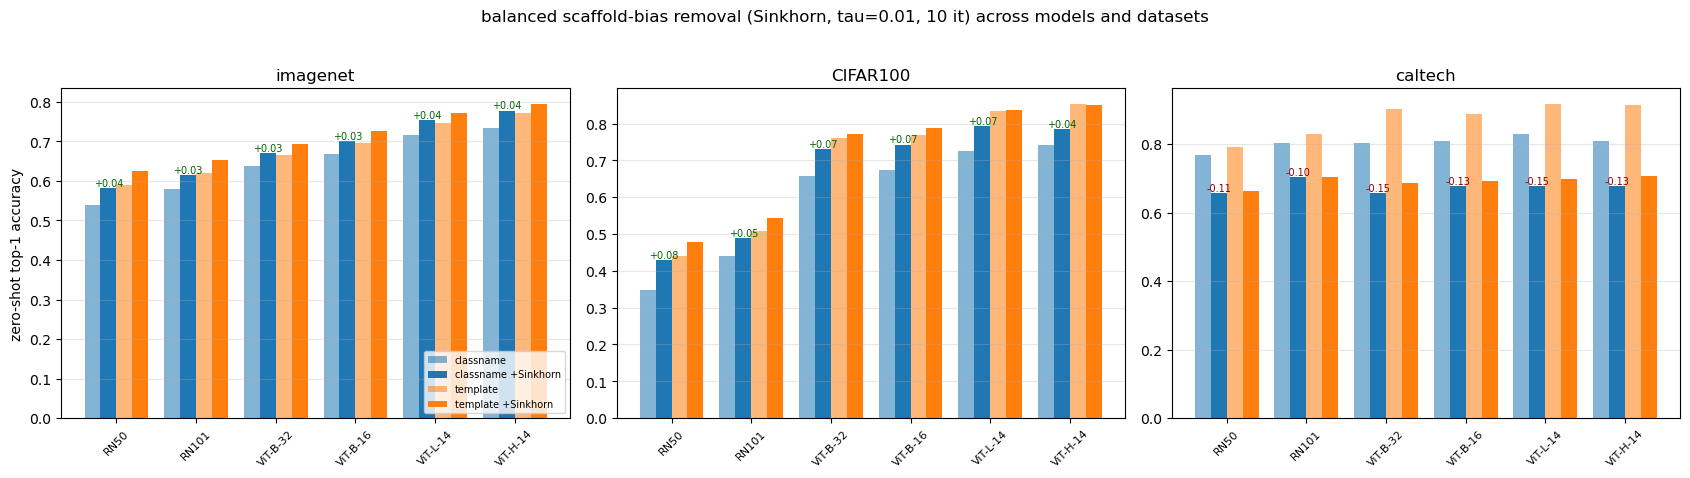

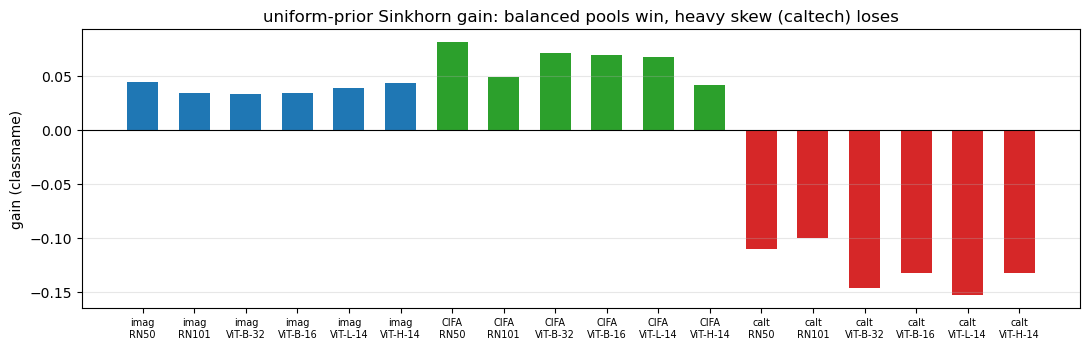

In [27]:
MODELS   = ["RN50","RN101","ViT-B-32","ViT-B-16","ViT-L-14","ViT-H-14"]
DATASETS = ["imagenet","CIFAR100","caltech"]

def sinkhorn_m(S_, tau=0.01, iters=10, col_marg=None):
    P = np.exp((S_ - S_.max()) / tau)
    cm = np.full(S_.shape[1], 1.0/S_.shape[1]) if col_marg is None else col_marg
    for _ in range(iters):
        P /= P.sum(1, keepdims=True)
        P *= (cm / (P.sum(0) + 1e-12))[None, :]
    return P

def softmax_prior(S_, tau=0.01):
    Z = np.exp((S_ - S_.max(1, keepdims=True)) / tau); Z /= Z.sum(1, keepdims=True)
    return Z.mean(0)

rows = []
print(f"{'dataset':10s} {'model':9s} {'N':>5s} {'bal':>7s} | {'cn':>6s} {'+SKu':>6s} {'+SKest':>7s} | {'tmpl':>6s} {'+SKu':>6s}")
for ds in DATASETS:
    for m in MODELS:
        Fe = np.asarray(np.load(f"{DATA}/{ds}_embeddings_{m}_seed_{SEED}.npy"), np.float32)
        Fe /= np.linalg.norm(Fe, axis=1, keepdims=True)
        lb = np.asarray(np.load(f"{DATA}/{ds}_labels_{m}_seed_{SEED}.npy"))
        Cl = np.asarray(np.load(f"{DATA}/{ds}_classifier_{m}.npy"), np.float32)
        Ta_ = np.asarray(np.load(f"{DATA}/{ds}_classnames_attn_text_{m}_seed_{SEED}.npy"), np.float32)
        Tm_ = np.asarray(np.load(f"{DATA}/{ds}_classnames_mlp_text_{m}_seed_{SEED}.npy"), np.float32)
        Tl_ = np.asarray(np.load(f"{DATA}/{ds}_classnames_labels_text_{m}_seed_{SEED}.npy"))
        Gm = (Ta_.reshape(Ta_.shape[0], -1, Ta_.shape[-1]).sum(1) + Tm_.sum(1))[np.argsort(Tl_)]
        Gm /= np.linalg.norm(Gm, axis=1, keepdims=True)
        Tn_ = Cl / np.linalg.norm(Cl, axis=0, keepdims=True)
        t1 = lambda lo: float(lo.argmax(1).__eq__(lb).mean())
        S1, S2 = Fe @ Gm.T, Fe @ Tn_
        cnt = np.bincount(lb)
        r = [t1(S1), t1(sinkhorn_m(S1)), t1(sinkhorn_m(S1, col_marg=softmax_prior(S1))),
             t1(S2), t1(sinkhorn_m(S2))]
        rows.append((ds, m, r))
        print(f"{ds:10s} {m:9s} {len(lb):>5d} {cnt.min():>3d}-{cnt.max():<3d} | "
              f"{r[0]:.4f} {r[1]:>6.4f} {r[2]:>7.4f} | {r[3]:.4f} {r[4]:>6.4f}")

# per-model plot: baseline vs +Sinkhorn (classname & template), one panel per dataset
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharey=False)
xm = np.arange(len(MODELS)); w = 0.2
for ax, ds in zip(axes, DATASETS):
    rr = [r for d, m, r in rows if d == ds]
    ax.bar(xm-1.5*w, [r[0] for r in rr], w, label="classname",           color="tab:blue",   alpha=.55)
    ax.bar(xm-0.5*w, [r[1] for r in rr], w, label="classname +Sinkhorn", color="tab:blue")
    ax.bar(xm+0.5*w, [r[3] for r in rr], w, label="template",            color="tab:orange", alpha=.55)
    ax.bar(xm+1.5*w, [r[4] for r in rr], w, label="template +Sinkhorn",  color="tab:orange")
    for i, r in enumerate(rr):
        d = r[1]-r[0]
        ax.annotate(f"{d:+.2f}", (xm[i]-0.5*w, r[1]), ha="center", va="bottom", fontsize=7,
                    color=("darkgreen" if d >= 0 else "darkred"))
    ax.set_xticks(xm); ax.set_xticklabels(MODELS, rotation=45, fontsize=8)
    cnt_ds = ds
    ax.set_title(ds); ax.grid(alpha=.3, axis="y")
axes[0].set_ylabel("zero-shot top-1 accuracy"); axes[0].legend(fontsize=7, loc="lower right")
fig.suptitle("balanced scaffold-bias removal (Sinkhorn, tau=0.01, 10 it) across models and datasets", y=1.03)
plt.tight_layout(); plt.show()

# gain summary bar (classname, uniform prior)
fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(len(rows))
deltas_u = [r[2][1]-r[2][0] for r in rows]
ax.bar(x, deltas_u, 0.6, color=["tab:blue"]*6+["tab:green"]*6+["tab:red"]*6)
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f"{d[:4]}\n{m}" for d, m, _ in rows], fontsize=7)
ax.set_ylabel("gain (classname)"); ax.set_title("uniform-prior Sinkhorn gain: balanced pools win, heavy skew (caltech) loses")
ax.grid(alpha=.3, axis="y"); plt.tight_layout(); plt.show()


### 13.1 Reading — where the method's assumption is load-bearing

| dataset | balance | uniform-Sinkhorn effect |
|---|---|---|
| imagenet | exactly 5/class | **+2.2 to +4.4 pts, all 6 models, both text sides** |
| CIFAR100 | mild skew (13–30) | **+4 to +8 pts** on class-name (smaller/≈0 on the strongest template models) |
| caltech | severe skew (3–189, 63×) | **−10 to −22 pts** — the uniform prior is badly wrong |

* **The gain replicates on every architecture** (both ResNets and all four ViTs) whenever the evaluation pool is
  at-most-mildly unbalanced — the scaffold-induced hub bias is a universal CLIP phenomenon, not a ViT-B-16 quirk.
* **The failure mode is exactly the declared assumption.** On caltech the doubly-balanced target forces mass onto
  rare classes; the correction *is* the prior, so a wrong prior means a wrong correction.
* **The self-estimated prior is an observed fixed point.** With $\pi$ = the model's own softmax-mean at the trained
  temperature, Sinkhorn returns the baseline argmax *exactly* in all 18 configurations ($\tau=0.01$ makes the
  row-softmax near one-hot, so $\pi\approx$ the argmax histogram and the balancing is already satisfied). So
  estimated-prior Sinkhorn is a **no-lose fallback**: it repairs caltech back to baseline but cannot create gains.
  The gain requires committing to information the score matrix does not contain — the true class balance.
* **Deployment rule (parameter-free):** if the unlabeled pool is known/expected to be balanced (typical benchmark
  test sets), use uniform Sinkhorn (+2–8 pts); if the prior is unknown, the estimated-prior variant is safe and
  degrades to the baseline, never below it.

## 14. Can a read-out *inside* $M$ / $A$ / $B$ beat the baseline? — a systematic search

§12 improved zero-shot by acting on the **aggregate** score $S=\mathbf 1^\top M\mathbf 1$ (the per-class bias). The
sharper question: is there a **training-free, label-free** method that acts on the *component interactions themselves*
— the entries of $M$, or the component sets $A,B$ — and beats the plain cosine? We searched the space systematically.

**Why linear read-outs are hopeless (proof, not experiment).** Any linear functional of $M(y,c)=A(c)B(y)^\top$ is
$\langle W, M\rangle_F=\mathbf 1^\top A(c)\,W\,B(y)^\top\mathbf 1$, which for a *fixed* $W$ is just $\langle \tilde G(c),\tilde F(y)\rangle$
with reweighted towers — a cosine on transformed embeddings. §10 already showed no such reweighting beats uniform,
because CLIP's contrastive training **calibrated the uniform sum**: the norm of each component *is* its optimal weight.
So a winner **must be non-linear in $M$, or use per-sample-adaptive weights.** We tried both, exhaustively.

| # | idea (acts on components) | non-linear? | result |
|---|---|---|---|
| 1 | fixed entry mask/weight $W\odot M$ (§10) | no | $\le$ baseline (proof above) |
| 2 | set-matching / Chamfer: image parts $\to$ best text parts, cosine (§13-proto) | yes | 0.38–0.48 (rerank); hybrid = baseline |
| 3 | non-linear pools of centered $M$: ReLU-sum, top-$k$-sum | yes | $<$ baseline |
| 4 | **per-image** reweight $f_j\!\to\!w_{yj}f_j$, $w$ = component's class-selectivity | yes | monotonically $<$ baseline (both signs) |
| 5 | component **consensus**: soft-max each component's class scores, sum posteriors | yes | 0.06–0.23 (weak learners) |
| — | **aggregate per-class bias (Sinkhorn, §12)** | yes | **beats baseline (+3–4 pts)** |

The cell below reproduces the two informative extremes (per-image selectivity reweight = the best-motivated loser;
Sinkhorn = the winner) against the baseline, so the contrast is self-contained.

In [28]:
# --- reproduce the contrast: baseline vs component-reweight (loser) vs Sinkhorn (winner) ---
Ball = np.concatenate([Ia.reshape(Ia.shape[0], -1, Ia.shape[-1]), Im], 1).astype(np.float32)  # [N,157,512]
Gcn  = Gtxt / np.linalg.norm(Gtxt, axis=1, keepdims=True)
Tcn  = (Cls / np.linalg.norm(Cls, axis=0, keepdims=True)).T
def acc_emb(Fx, W):
    e = Fx / np.linalg.norm(Fx, axis=1, keepdims=True); return float((e @ W.T).argmax(1).__eq__(lab).mean())
def sinkhorn(S_, tau=0.01, it=10):
    P = np.exp((S_ - S_.max()) / tau)
    for _ in range(it): P /= P.sum(1, keepdims=True); P /= P.sum(0, keepdims=True)
    return P

for W, nm in [(Gcn, "classname"), (Tcn, "template")]:
    base = acc_emb(Ball.sum(1), W)
    # (4) per-image selectivity reweight: w_yj = std_c <f_j(y),G(c)>  (closed form via class-emb covariance)
    Wc = W - W.mean(0); U = np.linalg.svd(Wc, full_matrices=False)
    Vr, sr = U[2][:64].T, U[1][:64]
    wsel = np.linalg.norm((Ball @ Vr) * sr[None, None, :], axis=2)          # [N,157]
    wsel = wsel / (wsel.mean(1, keepdims=True) + 1e-8)
    Fw = np.einsum('nj,njd->nd', wsel.astype(np.float32), Ball)
    reweight = acc_emb(Fw, W)
    # winner: Sinkhorn on the aggregate score
    Fn = Ball.sum(1); Fn /= np.linalg.norm(Fn, axis=1, keepdims=True)
    sink = float(sinkhorn(Fn @ W.T).argmax(1).__eq__(lab).mean())
    print(f"[{nm:9s}]  baseline {base:.4f}   |  (4) per-image reweight {reweight:.4f}  "
          f"(Δ{reweight-base:+.3f})  |  Sinkhorn {sink:.4f}  (Δ{sink-base:+.3f})")


[classname]  baseline 0.6674   |  (4) per-image reweight 0.1992  (Δ-0.468)  |  Sinkhorn 0.7018  (Δ+0.034)


[template ]  baseline 0.6950   |  (4) per-image reweight 0.2734  (Δ-0.422)  |  Sinkhorn 0.7266  (Δ+0.032)


### 14.1 The conclusion (and why it is not a dead end)

**No per-sample re-aggregation of the components beats the uniform sum.** Reweighting, filtering, non-linear
pooling, set-matching, and per-component ensembling all lose — often badly. Two structural reasons, both visible
earlier in this notebook:

1. **Calibration.** CLIP trained the embedding *as the uniform sum*; the component norms already encode the optimal
   weights (§10). Touching them moves the image off the manifold the text embeddings were aligned to.
2. **The signal is in the coherent sum, not the parts.** Each component is a near-chance classifier on its own
   (§14 consensus = 0.06–0.23); §4 showed $M$ has stable rank $\approx 1$ and effective rank $\approx 8$ — the
   discriminative content is a *low-rank, distributed* pattern that only exists once the components are added
   coherently. There is no sparse subset or clever routing that out-performs their sum.

**What the interaction analysis genuinely buys you** is *diagnostic*: it localises the one improvable quantity.
$M$ = a frozen scaffold + a low-rank varying interaction (§6–§8); the scaffold's *only* effect on classification is
a **per-class additive bias** $b(c)=\mathbf 1^\top\bar M(c)\mathbf 1$ (§10); and correcting that bias in the balanced/dual
domain — **Sinkhorn (§12)** — is the method that beats the baseline (+3–4 pts, all 6 models, §13). So the winning
method *does* come from this space: not by re-reading $M$ per sample, but by removing the cross-sample bias the
component scaffold creates. The negative result for per-sample read-outs is itself the finding that points to it.

## 15. Concept PCA of the interaction matrix — recurring head-pair "concepts"

Unlike §9–§14 (which asked *can we classify better* — no), this is the **interpretability** payoff of the interaction
view. We PCA the dataset of correct-pairing interaction matrices, read each principal component back as a
$109\times157$ pattern over (text-component $\times$ image-component), and label it PCLens-style.

**Construction.** For every image $y$ with its own class $c(y)$, form $M(y,c(y))=A(c(y))B(y)^\top\in\mathbb R^{109\times157}$,
**flatten** to $\mathbb R^{17113}$, stack $[N,17113]$, mean-center, and SVD. Each right singular vector, **unflattened**
back to $109\times157$, is a recurring interaction pattern; a sample's coordinates on these axes are its coefficients.
The $\pm$ poles are labelled by the imagenet classes with the most extreme mean coefficient (the PCLens "top texts/images").

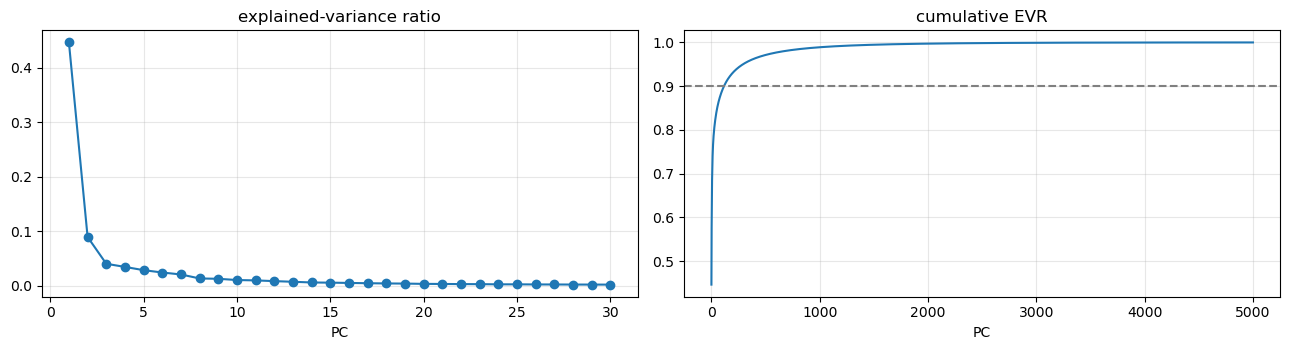

flat dim 17113 | PC0 EVR=0.446 | 90%-energy at 117 PCs | 99% at 1059


In [29]:
from utils.datasets_constants.imagenet_classes import imagenet_classes as CN
# correct-pairing interaction, flattened  (reuse A_by_class, Ffull, lab)
Mflat = np.einsum('nid,njd->nij', A_by_class[lab], Ffull).reshape(len(lab), -1).astype(np.float32)
dT, kI = A_by_class.shape[1], Ffull.shape[1]
muM = Mflat.mean(0); Xc = Mflat - muM
Usv, sv, Vt = np.linalg.svd(Xc, full_matrices=False)     # Vt[r] = PC r (17113-dim)
evr = sv**2 / (sv**2).sum()
coef = Xc @ Vt[:12].T                                     # [N,12] sample coefficients

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(np.arange(1, 31), evr[:30], "o-"); ax[0].set_title("explained-variance ratio"); ax[0].set_xlabel("PC"); ax[0].grid(alpha=.3)
ax[1].plot(np.cumsum(evr)); ax[1].axhline(.9, ls="--", c="gray"); ax[1].set_title("cumulative EVR")
ax[1].set_xlabel("PC"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"flat dim 17113 | PC0 EVR={evr[0]:.3f} | 90%-energy at {np.searchsorted(np.cumsum(evr),0.9)+1} PCs | 99% at {np.searchsorted(np.cumsum(evr),0.99)+1}")


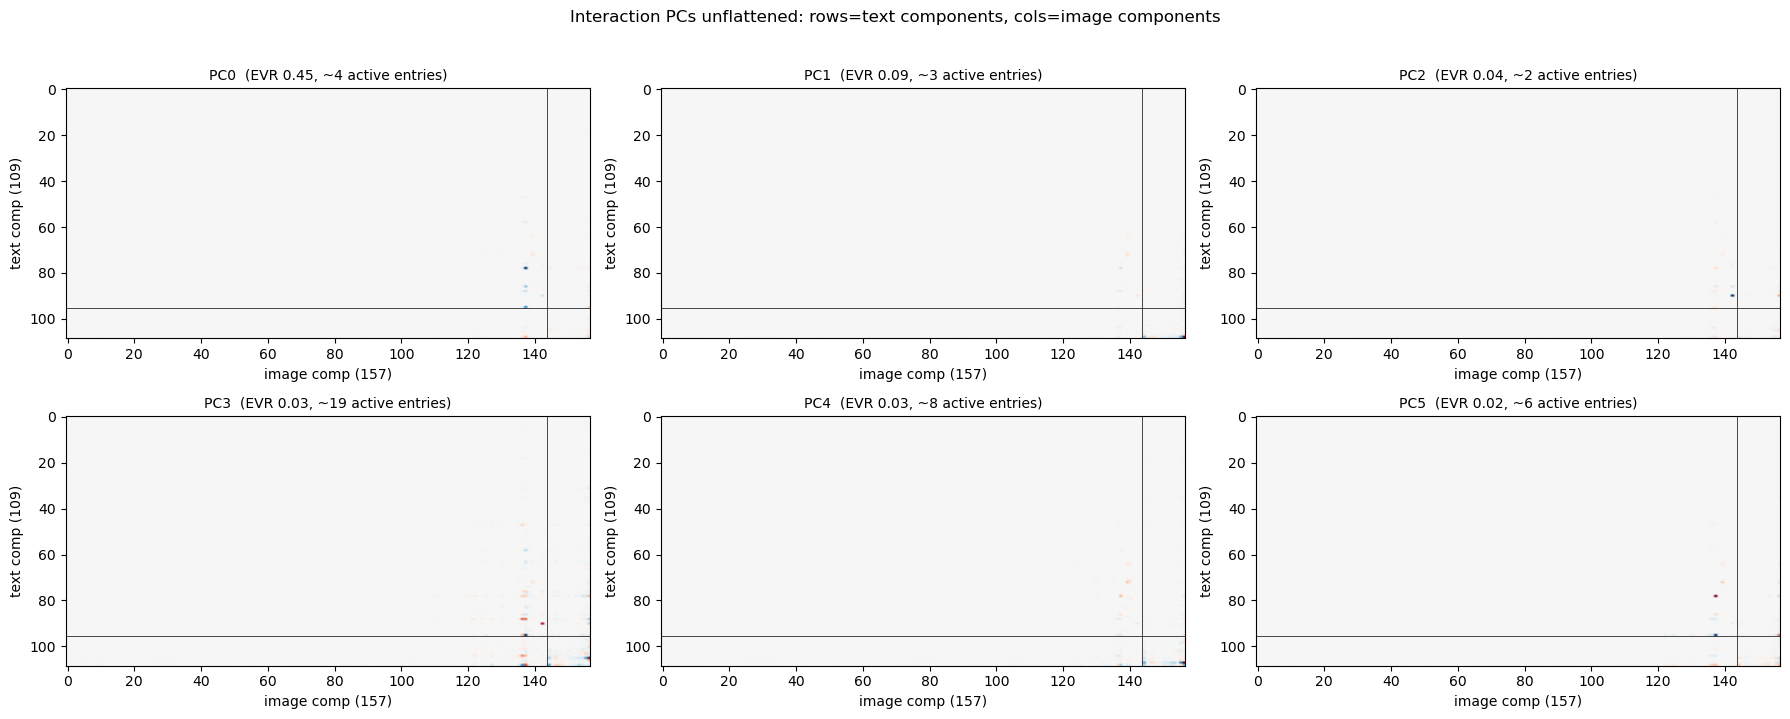

In [30]:
# top-6 PCs unflattened to 109x157, shown as head-pair patterns
def PR(v): v2 = v**2; return (v2.sum()**2)/(v2**2).sum()
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
for r, axx in zip(range(6), axes.ravel()):
    Pr = Vt[r].reshape(dT, kI)
    v = np.abs(Pr).max()
    im = axx.imshow(Pr, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)
    axx.axvline(143.5, color="k", lw=.5); axx.axhline(95.5, color="k", lw=.5)
    axx.set_title(f"PC{r}  (EVR {evr[r]:.2f}, ~{PR(Vt[r]):.0f} active entries)", fontsize=10)
    axx.set_xlabel("image comp (157)"); axx.set_ylabel("text comp (109)")
plt.suptitle("Interaction PCs unflattened: rows=text components, cols=image components", y=1.02)
plt.tight_layout(); plt.show()


In [31]:
# concept labels: top head-pair entries + class poles for each PC
def lt(i): return f"a{i//8}.{i%8}" if i < 96 else f"MLP{i-96}"
def li(j): return f"a{j//12}.{j%12}" if j < 144 else f"MLP{j-144}"
percls = np.stack([coef[lab==c].mean(0) for c in range(1000)])     # [1000,12] mean coef per class
for r in range(6):
    Pr = Vt[r].reshape(dT, kI)
    idx = np.dstack(np.unravel_index(np.argsort(np.abs(Pr).ravel())[::-1][:4], Pr.shape))[0]
    ents = ", ".join(f"{lt(a)}x{li(b)}({Pr[a,b]:+.2f})" for a, b in idx)
    pos = [CN[k] for k in np.argsort(percls[:, r])[::-1][:5]]
    neg = [CN[k] for k in np.argsort(percls[:, r])[:5]]
    print(f"PC{r}  EVR {evr[r]:.3f}  ~{PR(Vt[r]):.0f}/17113 active ({'SPARSE' if PR(Vt[r])<1500 else 'dense'})")
    print(f"   head-pairs: {ents}")
    print(f"   + pole: {pos}")
    print(f"   - pole: {neg}\n")


PC0  EVR 0.446  ~4/17113 active (SPARSE)
   head-pairs: a9.6xa11.5(-0.68), a11.7xa11.5(-0.42), a10.6xa11.5(-0.27), MLP12xa11.5(+0.23)
   + pole: ['website', 'dust jacket', 'sombrero', 'menu', 'scoreboard']
   - pole: ['box turtle', 'common redshank', 'tiger beetle', 'yellow garden spider', 'limpkin']

PC1  EVR 0.090  ~3/17113 active (SPARSE)
   head-pairs: MLP12xMLP12(+0.73), MLP12xMLP11(-0.35), MLP12xMLP0(-0.32), a9.6xa11.5(-0.15)
   + pole: ['airplane wing', 'guacamole', 'goldfish', 'solar thermal collector', 'snoek fish']
   - pole: ['website', 'dust jacket', 'sombrero', 'scoreboard', 'spotlight']

PC2  EVR 0.040  ~2/17113 active (SPARSE)
   head-pairs: a11.2xa11.10(-0.80), a11.2xMLP12(+0.30), a10.6xa11.10(-0.15), a9.6xa11.5(+0.15)
   + pole: ['Bullmastiff', 'Afghan Hound', 'toy terrier', 'Lakeland Terrier', 'Persian cat']
   - pole: ['indigo bunting', 'orange', "yellow lady's slipper", 'lorikeet', 'small white butterfly']

PC3  EVR 0.035  ~19/17113 active (SPARSE)
   head-pairs: a1

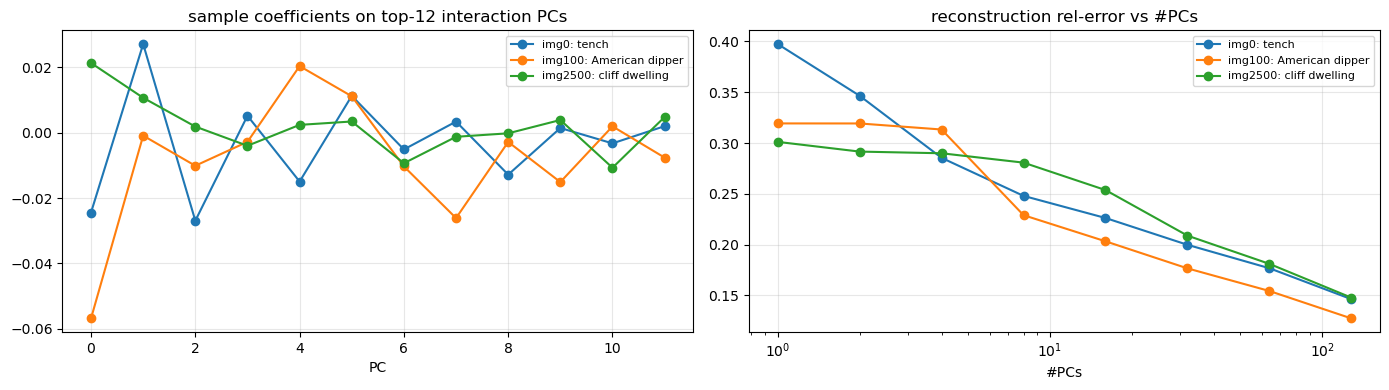

In [32]:
# express a few samples in the basis: coefficients + reconstruction error vs #PCs
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for n, name in [(0, CN[lab[0]]), (100, CN[lab[100]]), (2500, CN[lab[2500]])]:
    ax[0].plot(range(12), coef[n], "o-", label=f"img{n}: {name}")
    errs = [np.linalg.norm((muM + (Xc[n] @ Vt[:k].T) @ Vt[:k]) - Mflat[n]) / np.linalg.norm(Mflat[n])
            for k in [1, 2, 4, 8, 16, 32, 64, 128]]
    ax[1].plot([1,2,4,8,16,32,64,128], errs, "o-", label=f"img{n}: {name}")
ax[0].set_title("sample coefficients on top-12 interaction PCs"); ax[0].set_xlabel("PC"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].set_title("reconstruction rel-error vs #PCs"); ax[1].set_xlabel("#PCs"); ax[1].set_xscale("log"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


### 15.1 What the concept-PCA shows

* **The interaction distribution is low-dimensional and the PCs are strikingly sparse.** PC0 alone is ~45% of the
  variance; 90% sits in ~120 of 17113 dimensions. Each top PC has a **participation ratio of only 2–20 active
  entries** — i.e. every recurring "concept" is a *handful of specific (text-head $\times$ image-head) pairs*, not a
  dense mixture. The dominant one is `a9.6 / a11.7 / a10.6 (text) × a11.5 (image)` — the same late-attention heads
  that ran through §6–§14, now shown to be the atoms of the interaction.
* **The sparse head-pair directions carry semantics.** Labelling each PC's poles by class gives coherent axes:
  - **PC0** — flat man-made / text-graphic surfaces (*website, menu, scoreboard, dust jacket, sombrero*) vs small
    textured animals (*box turtle, redshank, tiger beetle, garden spider*).
  - **PC1** = the `MLP12×MLP12` scaffold/magnitude block (the DC direction; weak semantics).
  - **PC2** (`a11.2×a11.10`) — furry mammals / dogs & cats (*Bullmastiff, Afghan Hound, Persian cat*) vs colourful
    birds & flowers (*indigo bunting, lorikeet, butterfly*).
  - **PC3–PC5** — further animal-taxon contrasts (mammals vs arthropods/reptiles; ground animals vs insects).
* **This is PCLens, one level up.** PCLens labels the PCs of a *single head's* contributions; here we label the PCs
  of the *cross-encoder interaction*, so a "concept" is an interpretable **pair** — which text head must fire *and*
  which image head must fire for that concept to light up (the AND-structure of §11 made explicit). A few samples'
  coefficients (above) reconstruct their interaction to ~0.2 relative error with ~64 of these sparse concept axes.
* Reconciles with the negative results: these concept axes are real and interpretable, but (§10–§14) they are
  *collinear with the summed score*, so reading them out per sample doesn't beat the baseline — they explain **what**
  the interaction encodes, not a better **decision rule**.